<h2 style="color:#111111; border-left:5px solid #111111; padding-left:12px;"> 1. 실행 환경 설정 </h2>

In [1]:
from pathlib import Path
import os

IN_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ
IN_COLAB = False

if IN_KAGGLE:
    PROJECT_ROOT = Path('/kaggle/working/wardy')
    RUNTIME_ROOT = Path('/kaggle/working')
else:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        IN_COLAB = True
    except ImportError:
        pass

    PROJECT_ROOT = (
        Path('/content/drive/MyDrive/wardy')
        if IN_COLAB else Path(r'D:\wardy')
    )
    RUNTIME_ROOT = Path('/content') if IN_COLAB else PROJECT_ROOT / '.runtime'

RUNTIME_ROOT.mkdir(parents=True, exist_ok=True)
PROJECT_ROOT.mkdir(parents=True, exist_ok=True)

ENVIRONMENT = 'Kaggle' if IN_KAGGLE else ('Google Colab' if IN_COLAB else 'VS Code 로컬')
print('실행 환경:', ENVIRONMENT)
print('프로젝트 경로:', PROJECT_ROOT)

실행 환경: Kaggle
프로젝트 경로: /kaggle/working/wardy


<h2 style="color:#111111; border-left:5px solid #111111; padding-left:12px;"> 2. 데이터셋 ZIP 파일 경로 설정 </h2>

In [2]:
from pathlib import Path

search_root = (
    Path('/kaggle/input') if IN_KAGGLE
    else (Path('/content/drive/MyDrive') if IN_COLAB else PROJECT_ROOT)
)
zip_matches = list(search_root.rglob('person_dataset_merged.zip'))
yaml_matches = list(search_root.rglob('data.yaml')) if IN_KAGGLE else []

if zip_matches:
    DATA_SOURCE_TYPE = 'zip'
    ZIP_PATH = zip_matches[0]
    LOCAL_ZIP = RUNTIME_ROOT / 'person_dataset_merged.zip'
    print('ZIP 데이터셋:', ZIP_PATH)
elif yaml_matches:
    DATA_SOURCE_TYPE = 'folder'
    SOURCE_DATASET_PATH = yaml_matches[0].parent
    print('압축 해제된 데이터셋:', SOURCE_DATASET_PATH)
else:
    raise FileNotFoundError(
        f'데이터셋을 찾을 수 없습니다: {search_root}. '
        'Kaggle 우측 Add Input으로 person 데이터셋을 추가하세요.'
    )

압축 해제된 데이터셋: /kaggle/input/datasets/jjm1595/person-dataset-merged/person_dataset


<h2 style="color:#111111; border-left:5px solid #111111; padding-left:12px;"> 3. ZIP 파일 실행 환경으로 복사 </h2>

In [3]:
import shutil

DATASET_PATH = RUNTIME_ROOT / 'person_dataset'

if DATA_SOURCE_TYPE == 'zip':
    shutil.copy2(ZIP_PATH, LOCAL_ZIP)
    print('ZIP 파일 복사 완료:', LOCAL_ZIP)
else:
    shutil.copytree(SOURCE_DATASET_PATH, DATASET_PATH, dirs_exist_ok=True)
    print('데이터셋 폴더 복사 완료:', DATASET_PATH)

데이터셋 폴더 복사 완료: /kaggle/working/person_dataset


<h2 style="color:#111111; border-left:5px solid #111111; padding-left:12px;"> 4. 데이터셋 ZIP 파일 압축 해제 </h2>

In [4]:
if DATA_SOURCE_TYPE == 'zip':
    import zipfile

    with zipfile.ZipFile(LOCAL_ZIP, 'r') as zip_ref:
        zip_ref.extractall(RUNTIME_ROOT)
    print('압축 해제 완료')
else:
    print('Kaggle에서 이미 압축 해제된 데이터셋을 사용합니다.')

Kaggle에서 이미 압축 해제된 데이터셋을 사용합니다.


<h2 style="color:#111111; border-left:5px solid #111111; padding-left:12px;"> 5. 데이터셋 경로 설정 </h2>

In [5]:
DATASET_PATH = RUNTIME_ROOT / 'person_dataset'
DATA_YAML = DATASET_PATH / 'data.yaml'

print(DATASET_PATH)
print(DATA_YAML)

/kaggle/working/person_dataset
/kaggle/working/person_dataset/data.yaml


<h2 style="color:#111111; border-left:5px solid #111111; padding-left:12px;"> 6. data.yaml 경로 수정 </h2>

In [6]:
from pathlib import Path

yaml_path = Path(DATA_YAML)

text = yaml_path.read_text(encoding="utf-8")
text = text.replace("path: .", f"path: {DATASET_PATH.as_posix()}")

yaml_path.write_text(text, encoding="utf-8")

print(yaml_path.read_text(encoding="utf-8"))

path: /kaggle/working/person_dataset
train: images/train
val: images/val
test: images/test

names:
  0: person



<h2 style="color:#111111; border-left:5px solid #111111; padding-left:12px;"> 7. Ultralytics YOLO 설치 </h2>

In [7]:
!pip install -q ultralytics

from ultralytics import settings
settings.update({'raytune': False})
print('Ray Tune 비활성화:', settings['raytune'] is False)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ray Tune 비활성화: True


<h2 style="color:#111111; border-left:5px solid #111111; padding-left:12px;"> 8. GPU 사용 가능 여부 확인 </h2>

In [8]:
import torch

if not torch.cuda.is_available():
    raise RuntimeError(
        'CUDA GPU가 할당되지 않았습니다. Kaggle에서는 Settings > Accelerator를 GPU로, '
        'Colab에서는 런타임 유형을 T4 GPU로 변경하세요.'
    )

DEVICE = 0
print('CUDA 사용 가능:', True)
print('PyTorch:', torch.__version__)
print('CUDA:', torch.version.cuda)
print('GPU:', torch.cuda.get_device_name(DEVICE))
print('GPU 개수:', torch.cuda.device_count())

CUDA 사용 가능: True
PyTorch: 2.10.0+cu128
CUDA: 12.8
GPU: Tesla T4
GPU 개수: 2


<h2 style="color:#111111; border-left:5px solid #111111; padding-left:12px;"> 9. 5 Epoch 시험 학습 </h2>

In [9]:
from ultralytics import YOLO
from pathlib import Path

RUN_DIR = PROJECT_ROOT / 'ml/src/export/person_detector_smoke_test'
SMOKE_BACKUP_VERIFIED = False
model = YOLO('yolo11n.pt')
results = model.train(
    data=DATA_YAML,
    epochs=5,
    imgsz=640,
    batch=8,
    device=DEVICE,
    workers=2,
    project=str(RUN_DIR.parent),
    name=RUN_DIR.name,
    exist_ok=True,
    seed=42,
    plots=True,
)

Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/person_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=person_detector_smoke_t

<h2 style="color:#111111; border-left:5px solid #111111; padding-left:12px;"> 10. 시험 학습 결과 확인 </h2>

<h3 style="color:#111111; border-left:3px solid #111111; padding-left:8px;"> 1. 결과 폴더와 생성 파일 확인 </h3>

In [10]:
from IPython.display import display, Image
print('결과 폴더:', RUN_DIR)
print('폴더 존재:', RUN_DIR.exists())
if RUN_DIR.exists():
    for item in sorted(RUN_DIR.iterdir()):
        print(item.name)

결과 폴더: /kaggle/working/wardy/ml/src/export/person_detector_smoke_test
폴더 존재: True
BoxF1_curve.png
BoxPR_curve.png
BoxP_curve.png
BoxR_curve.png
args.yaml
confusion_matrix.png
confusion_matrix_normalized.png
labels.jpg
results.csv
results.png
train_batch0.jpg
train_batch1.jpg
train_batch2.jpg
val_batch0_labels.jpg
val_batch0_pred.jpg
val_batch1_labels.jpg
val_batch1_pred.jpg
val_batch2_labels.jpg
val_batch2_pred.jpg
weights


<h3 style="color:#111111; border-left:3px solid #111111; padding-left:8px;"> 2. 학습 이미지와 정답 라벨 확인 </h3>

train_batch0.jpg


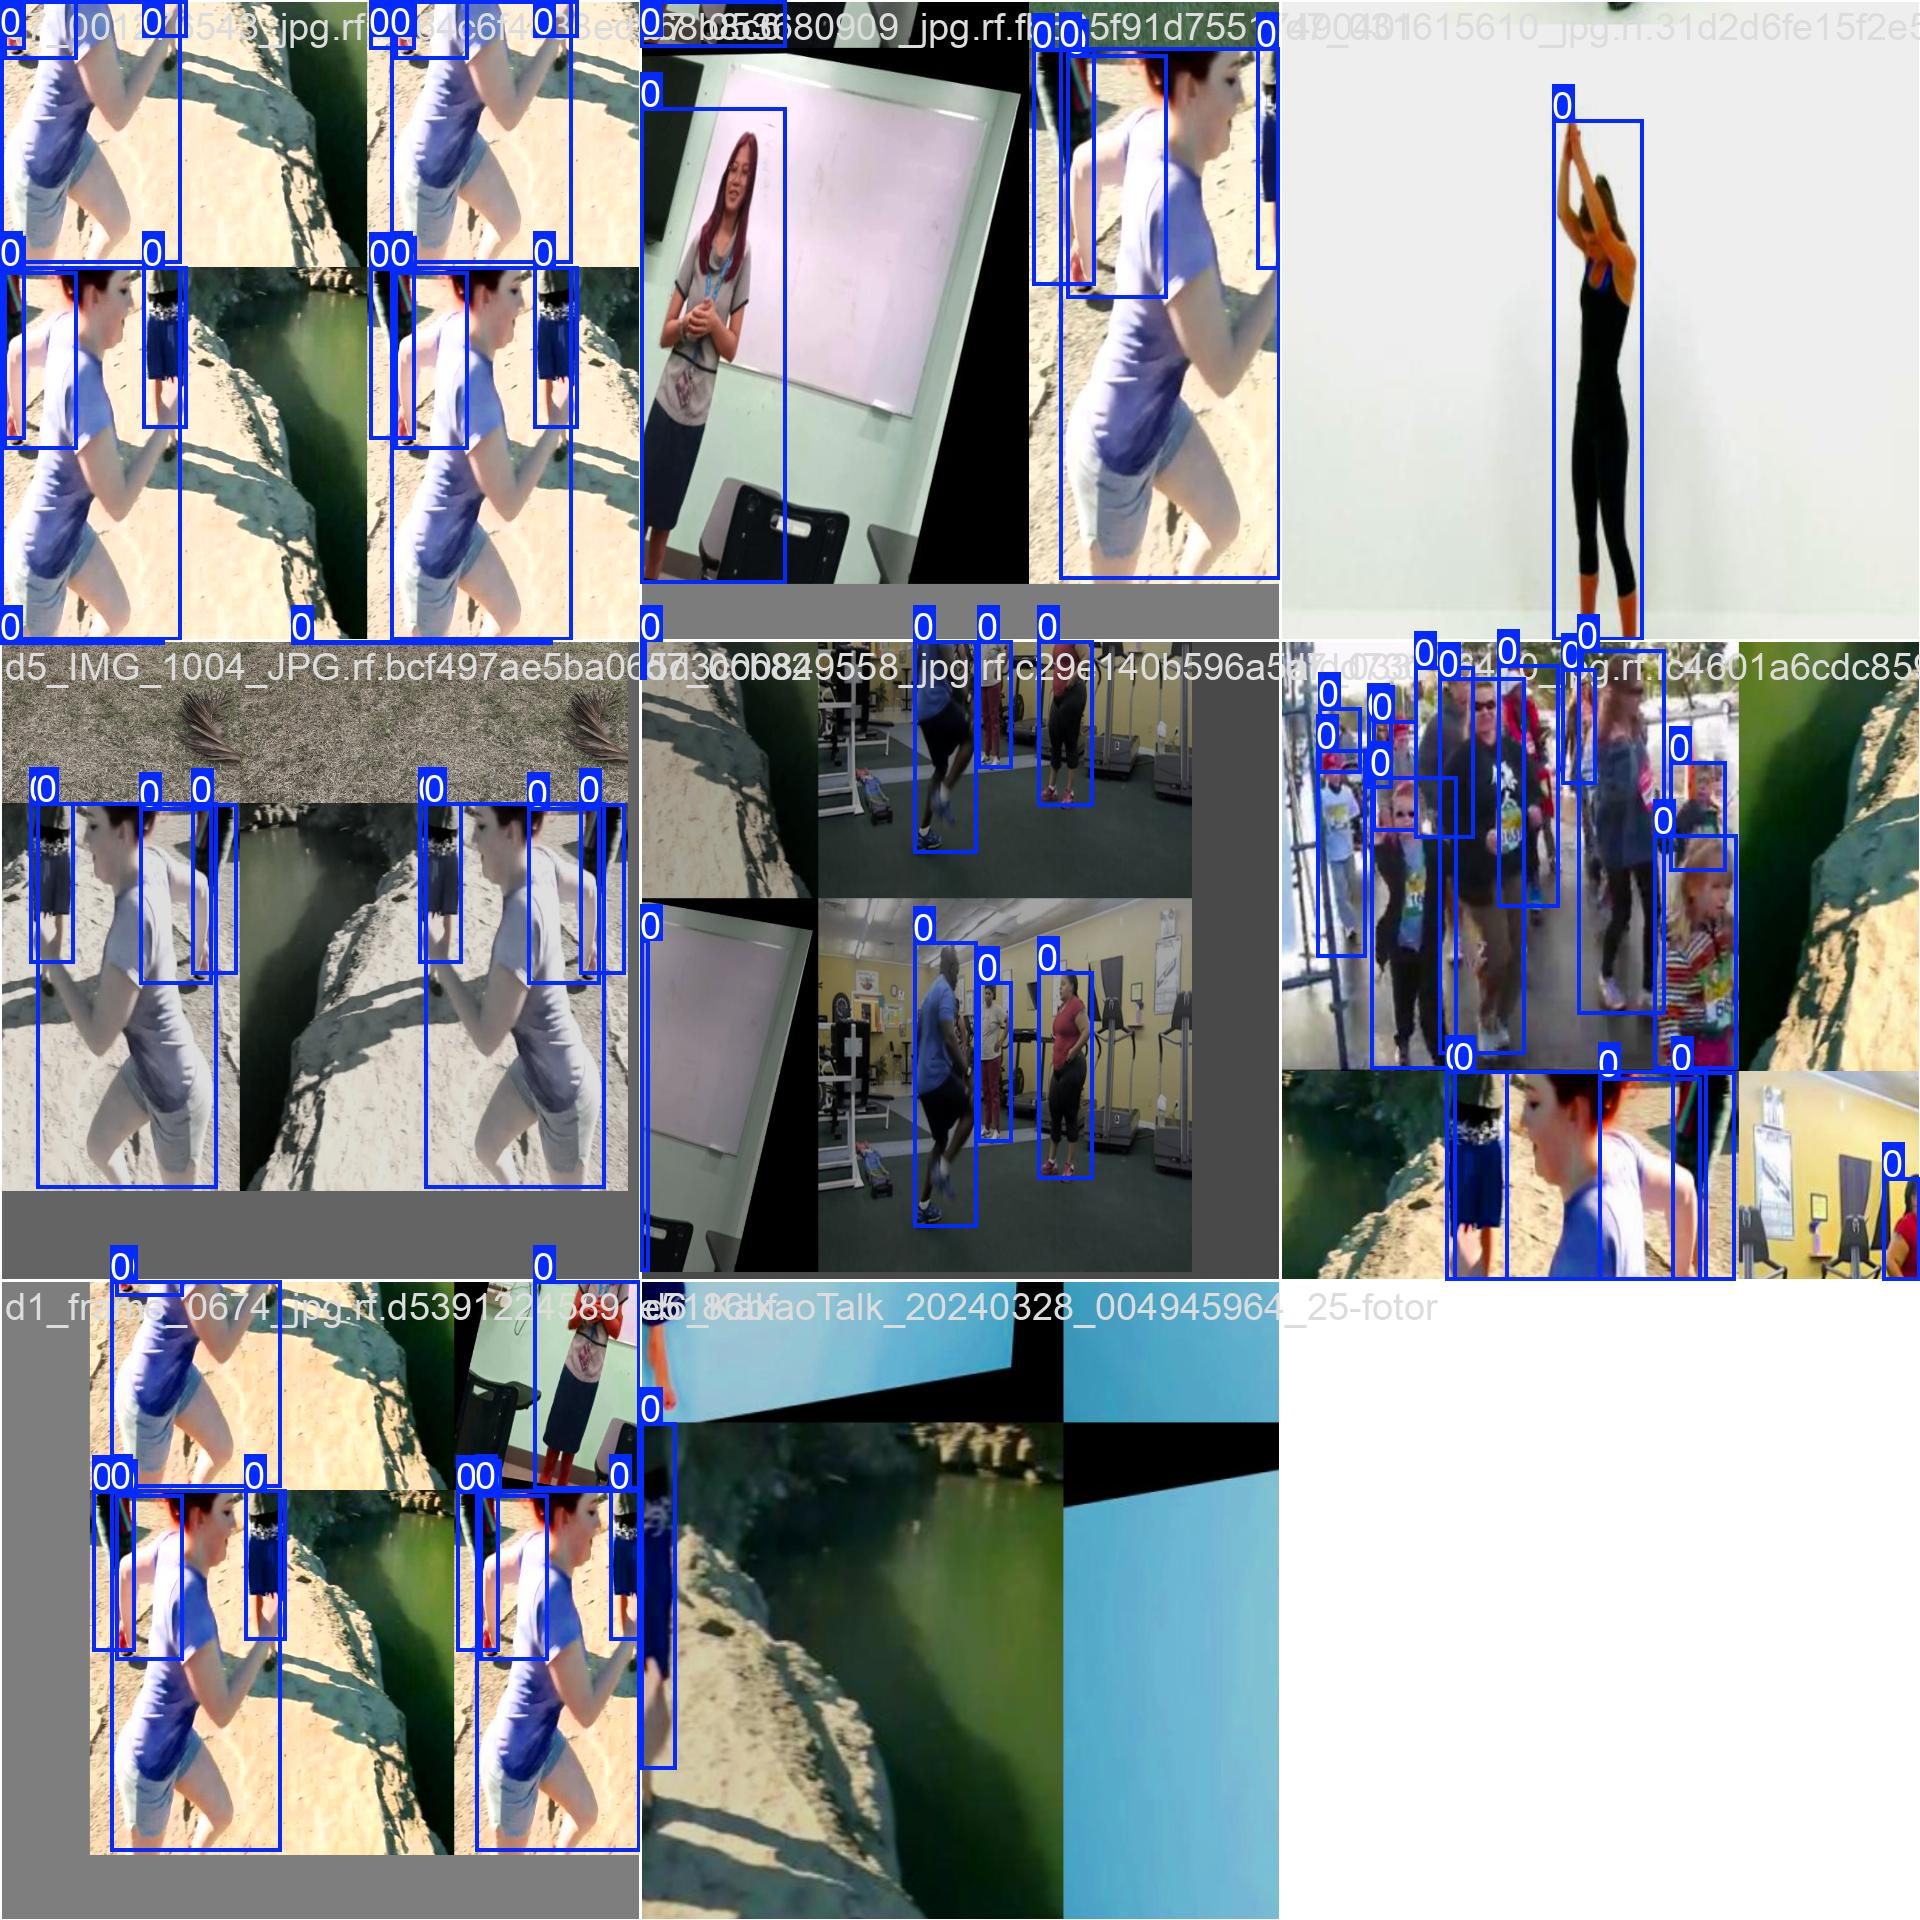

train_batch1.jpg


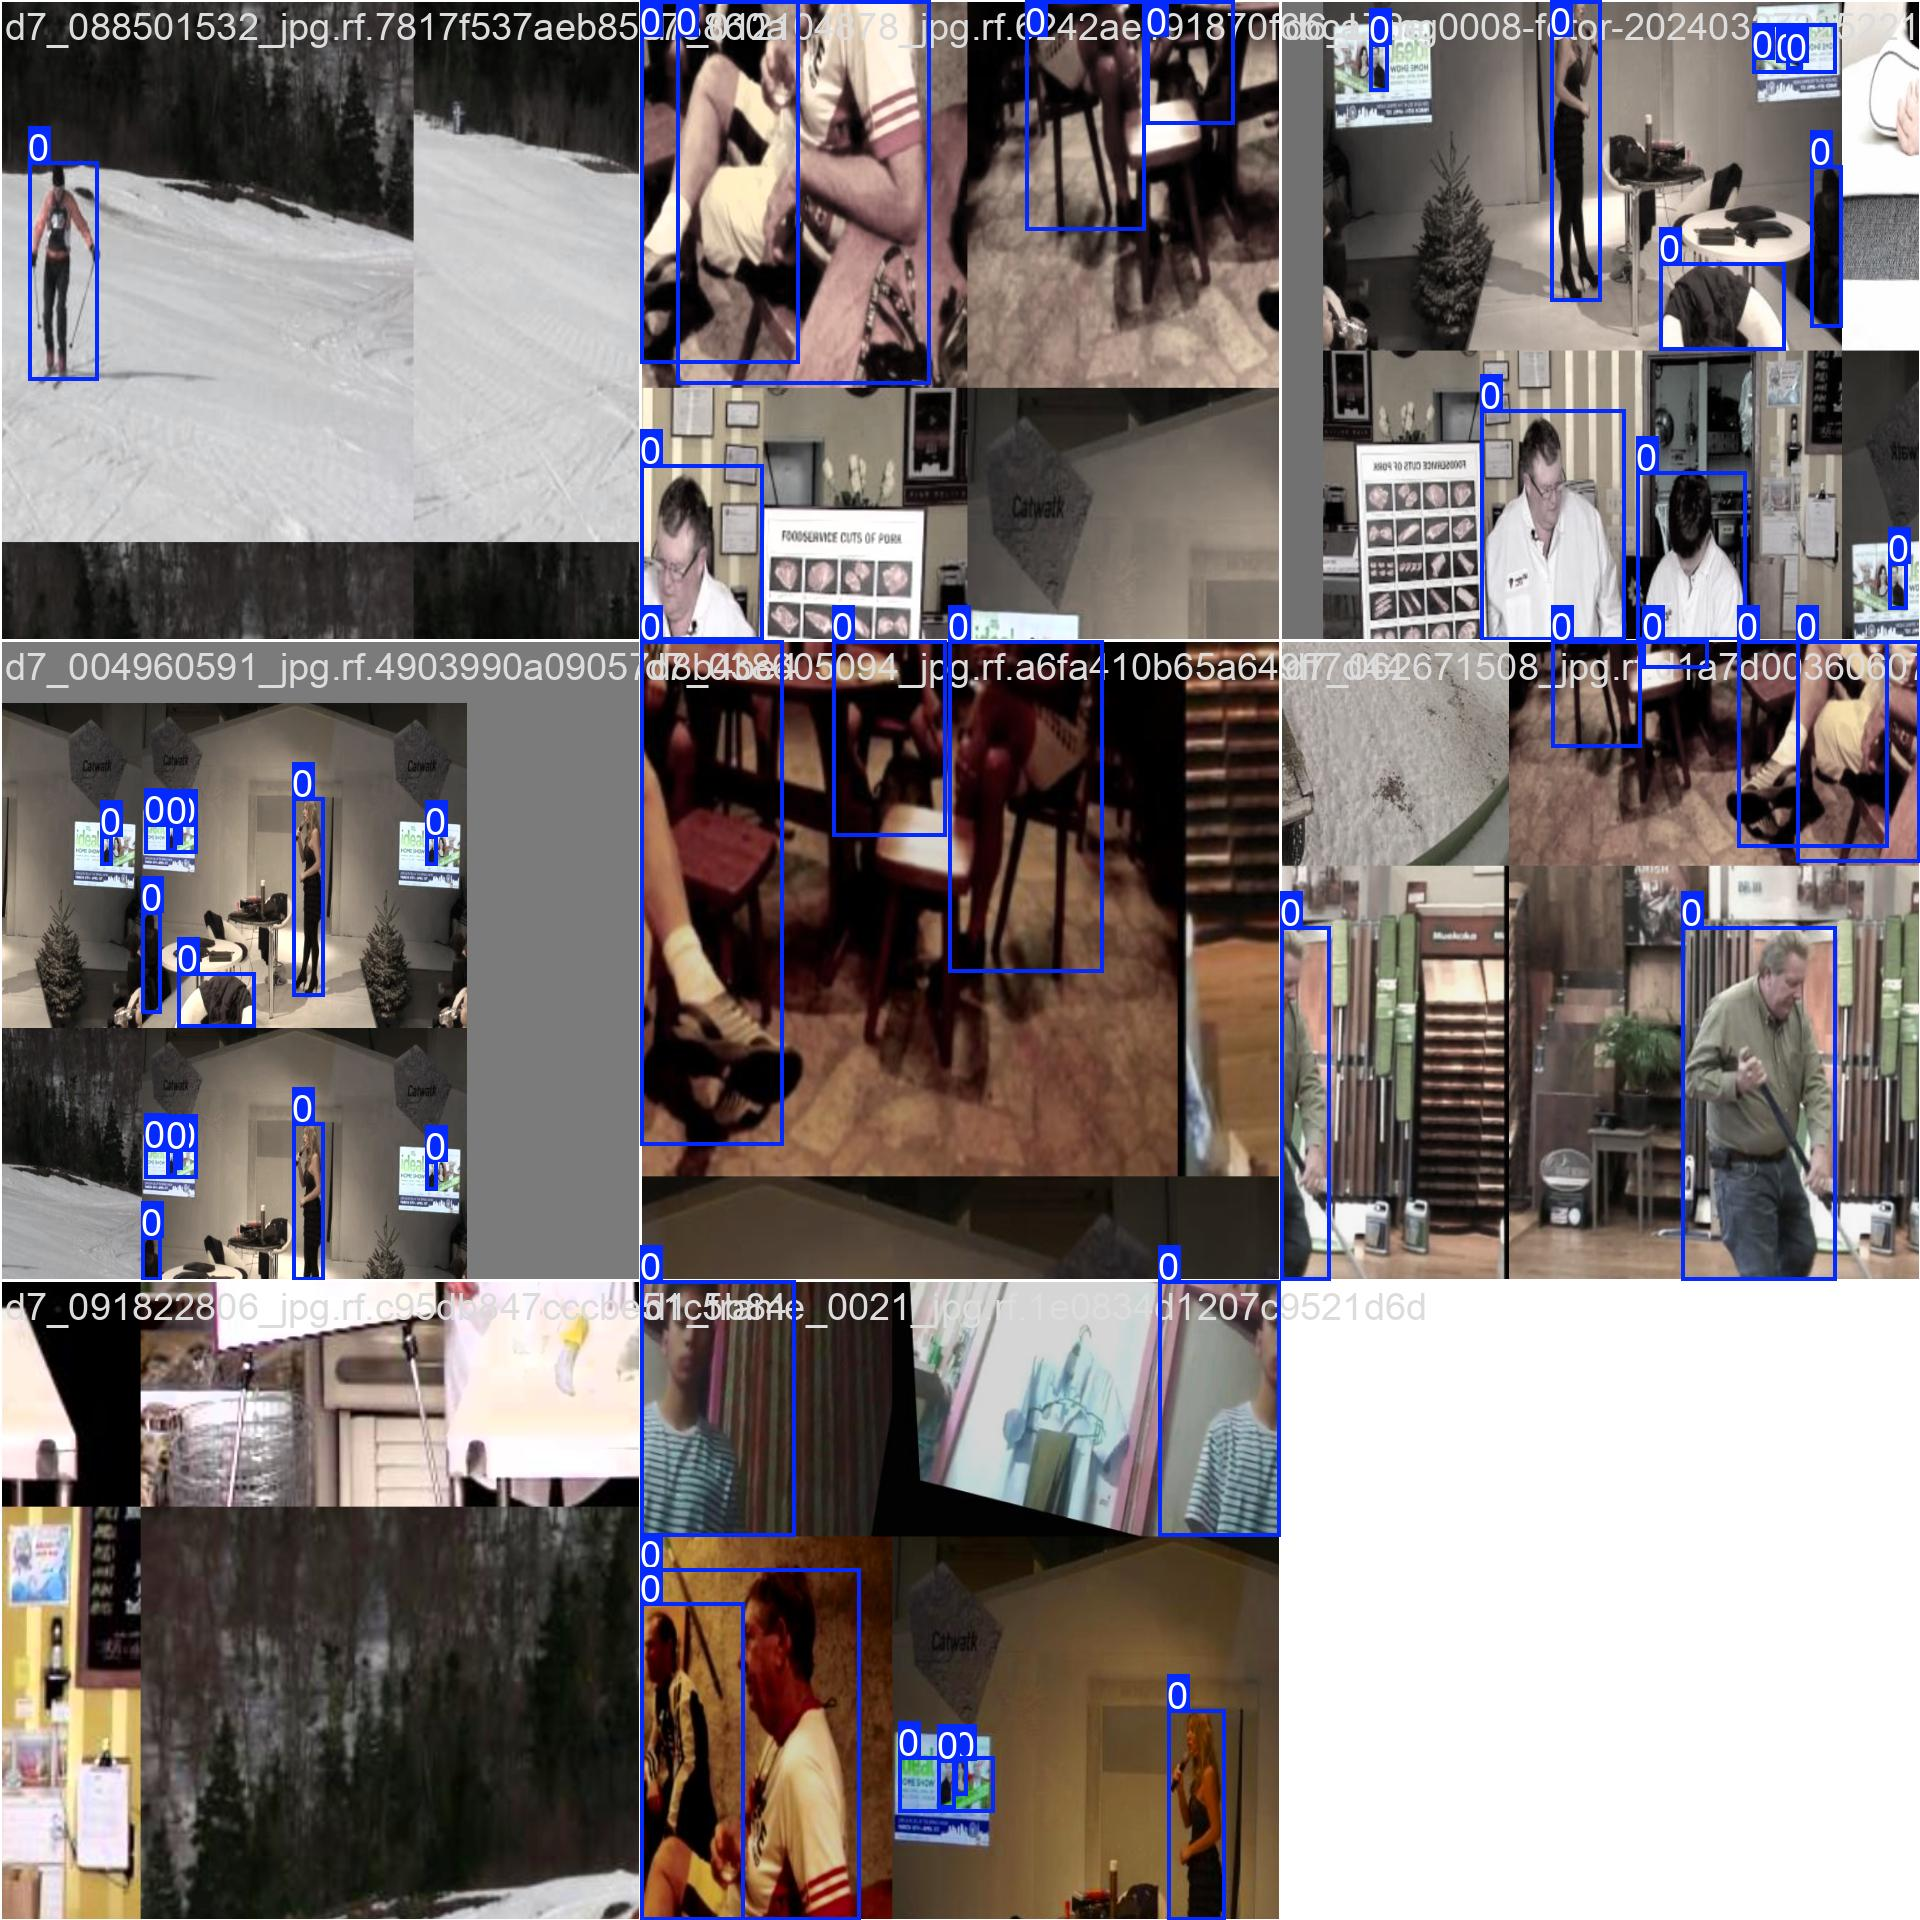

train_batch2.jpg


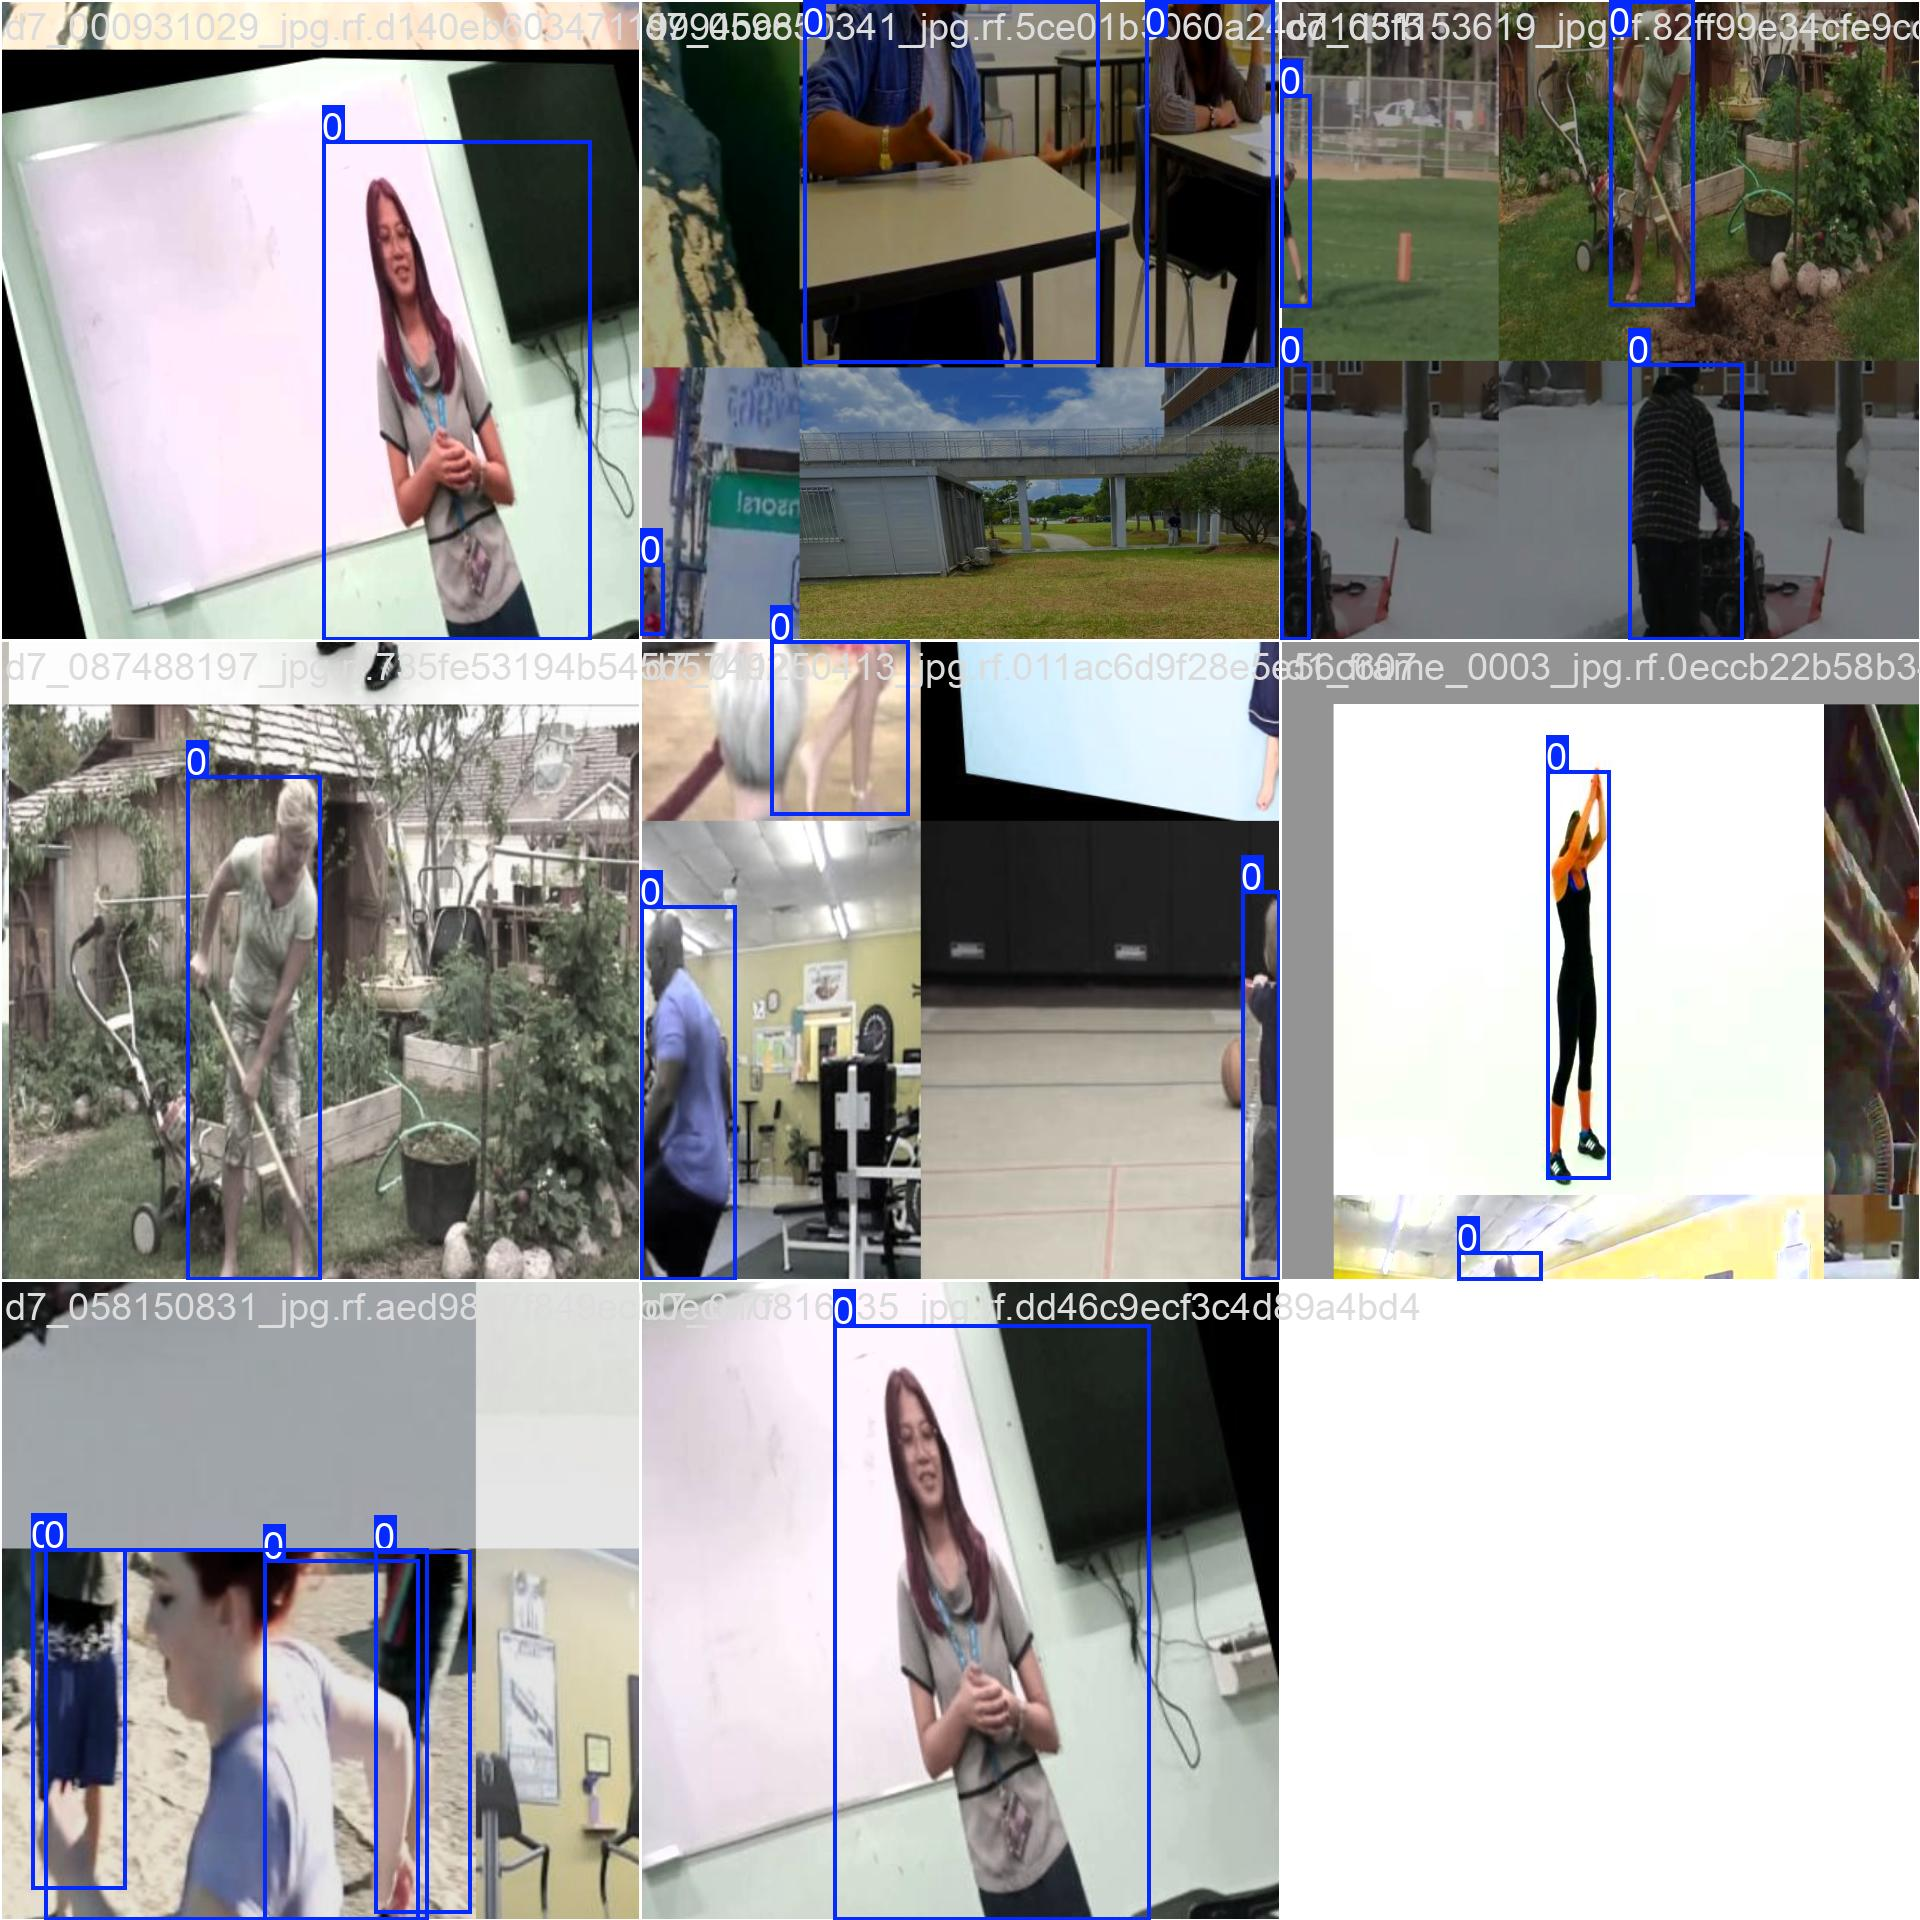

In [11]:
for filename in ['train_batch0.jpg', 'train_batch1.jpg', 'train_batch2.jpg']:
    image_path = RUN_DIR / filename
    if image_path.exists():
        print(filename)
        display(Image(filename=str(image_path), width=1000))

<h3 style="color:#111111; border-left:3px solid #111111; padding-left:8px;"> 3. 검증 정답과 모델 예측 비교 </h3>

val_batch0_labels.jpg


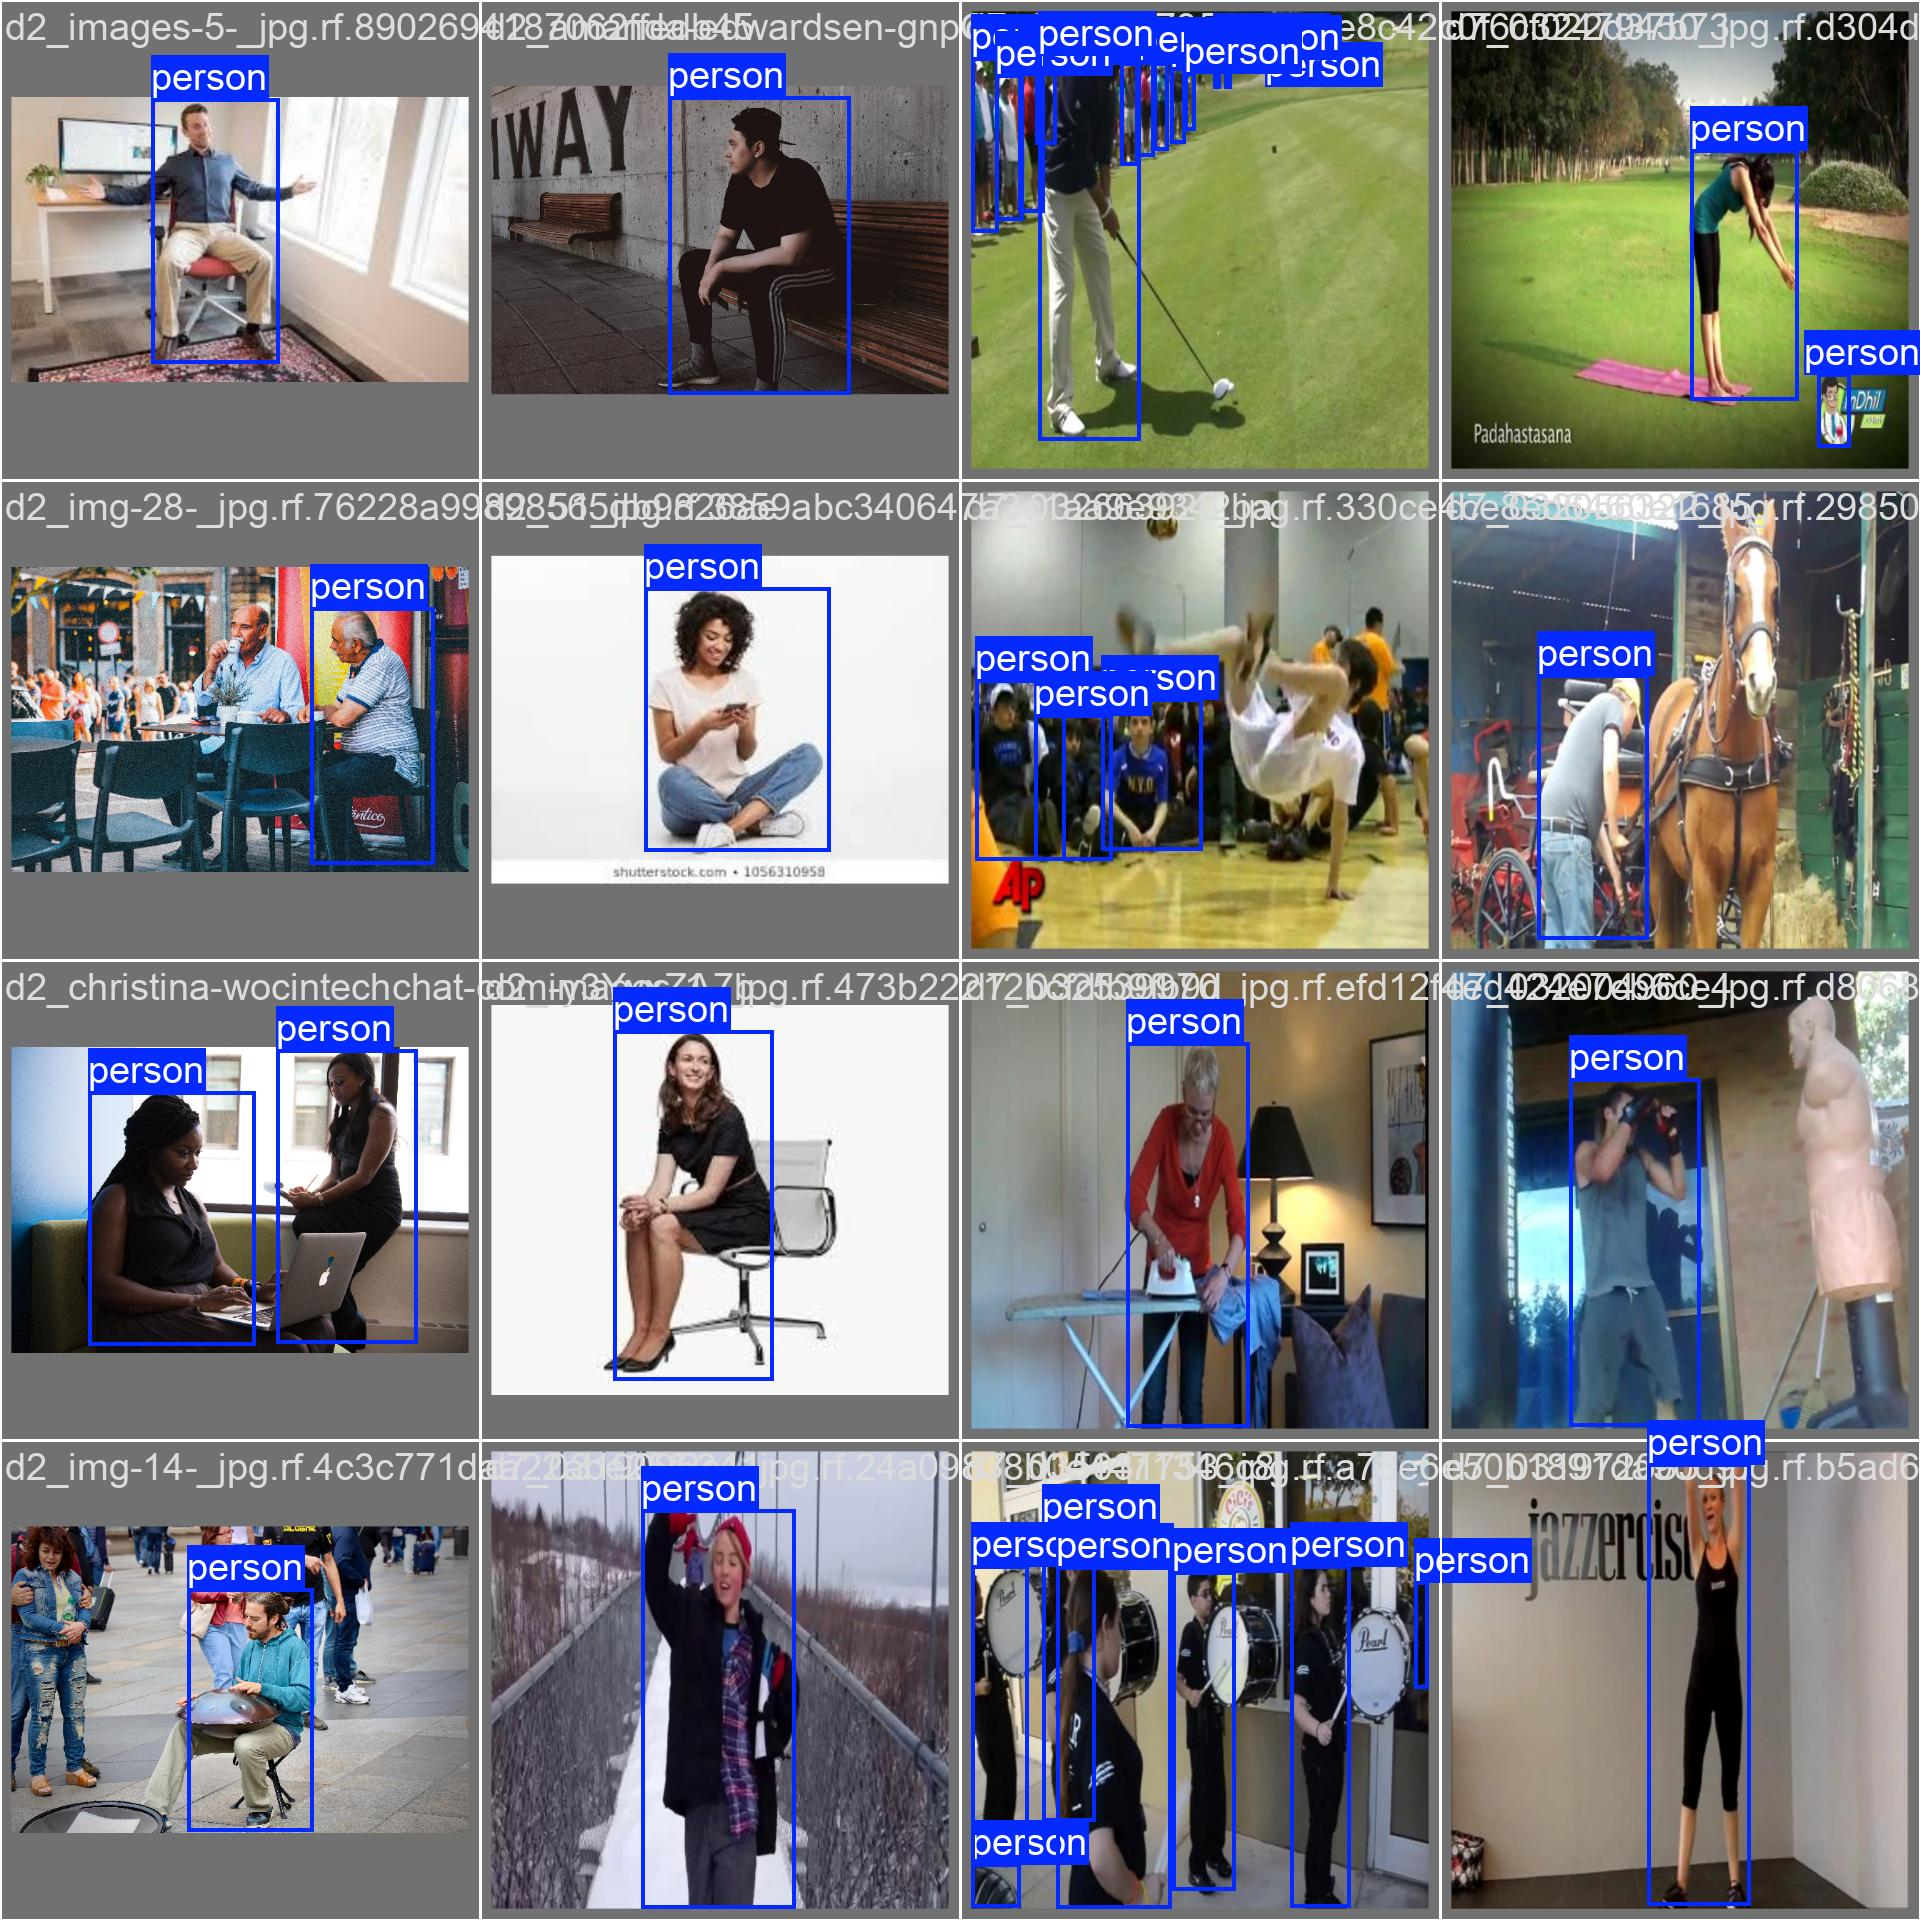

val_batch0_pred.jpg


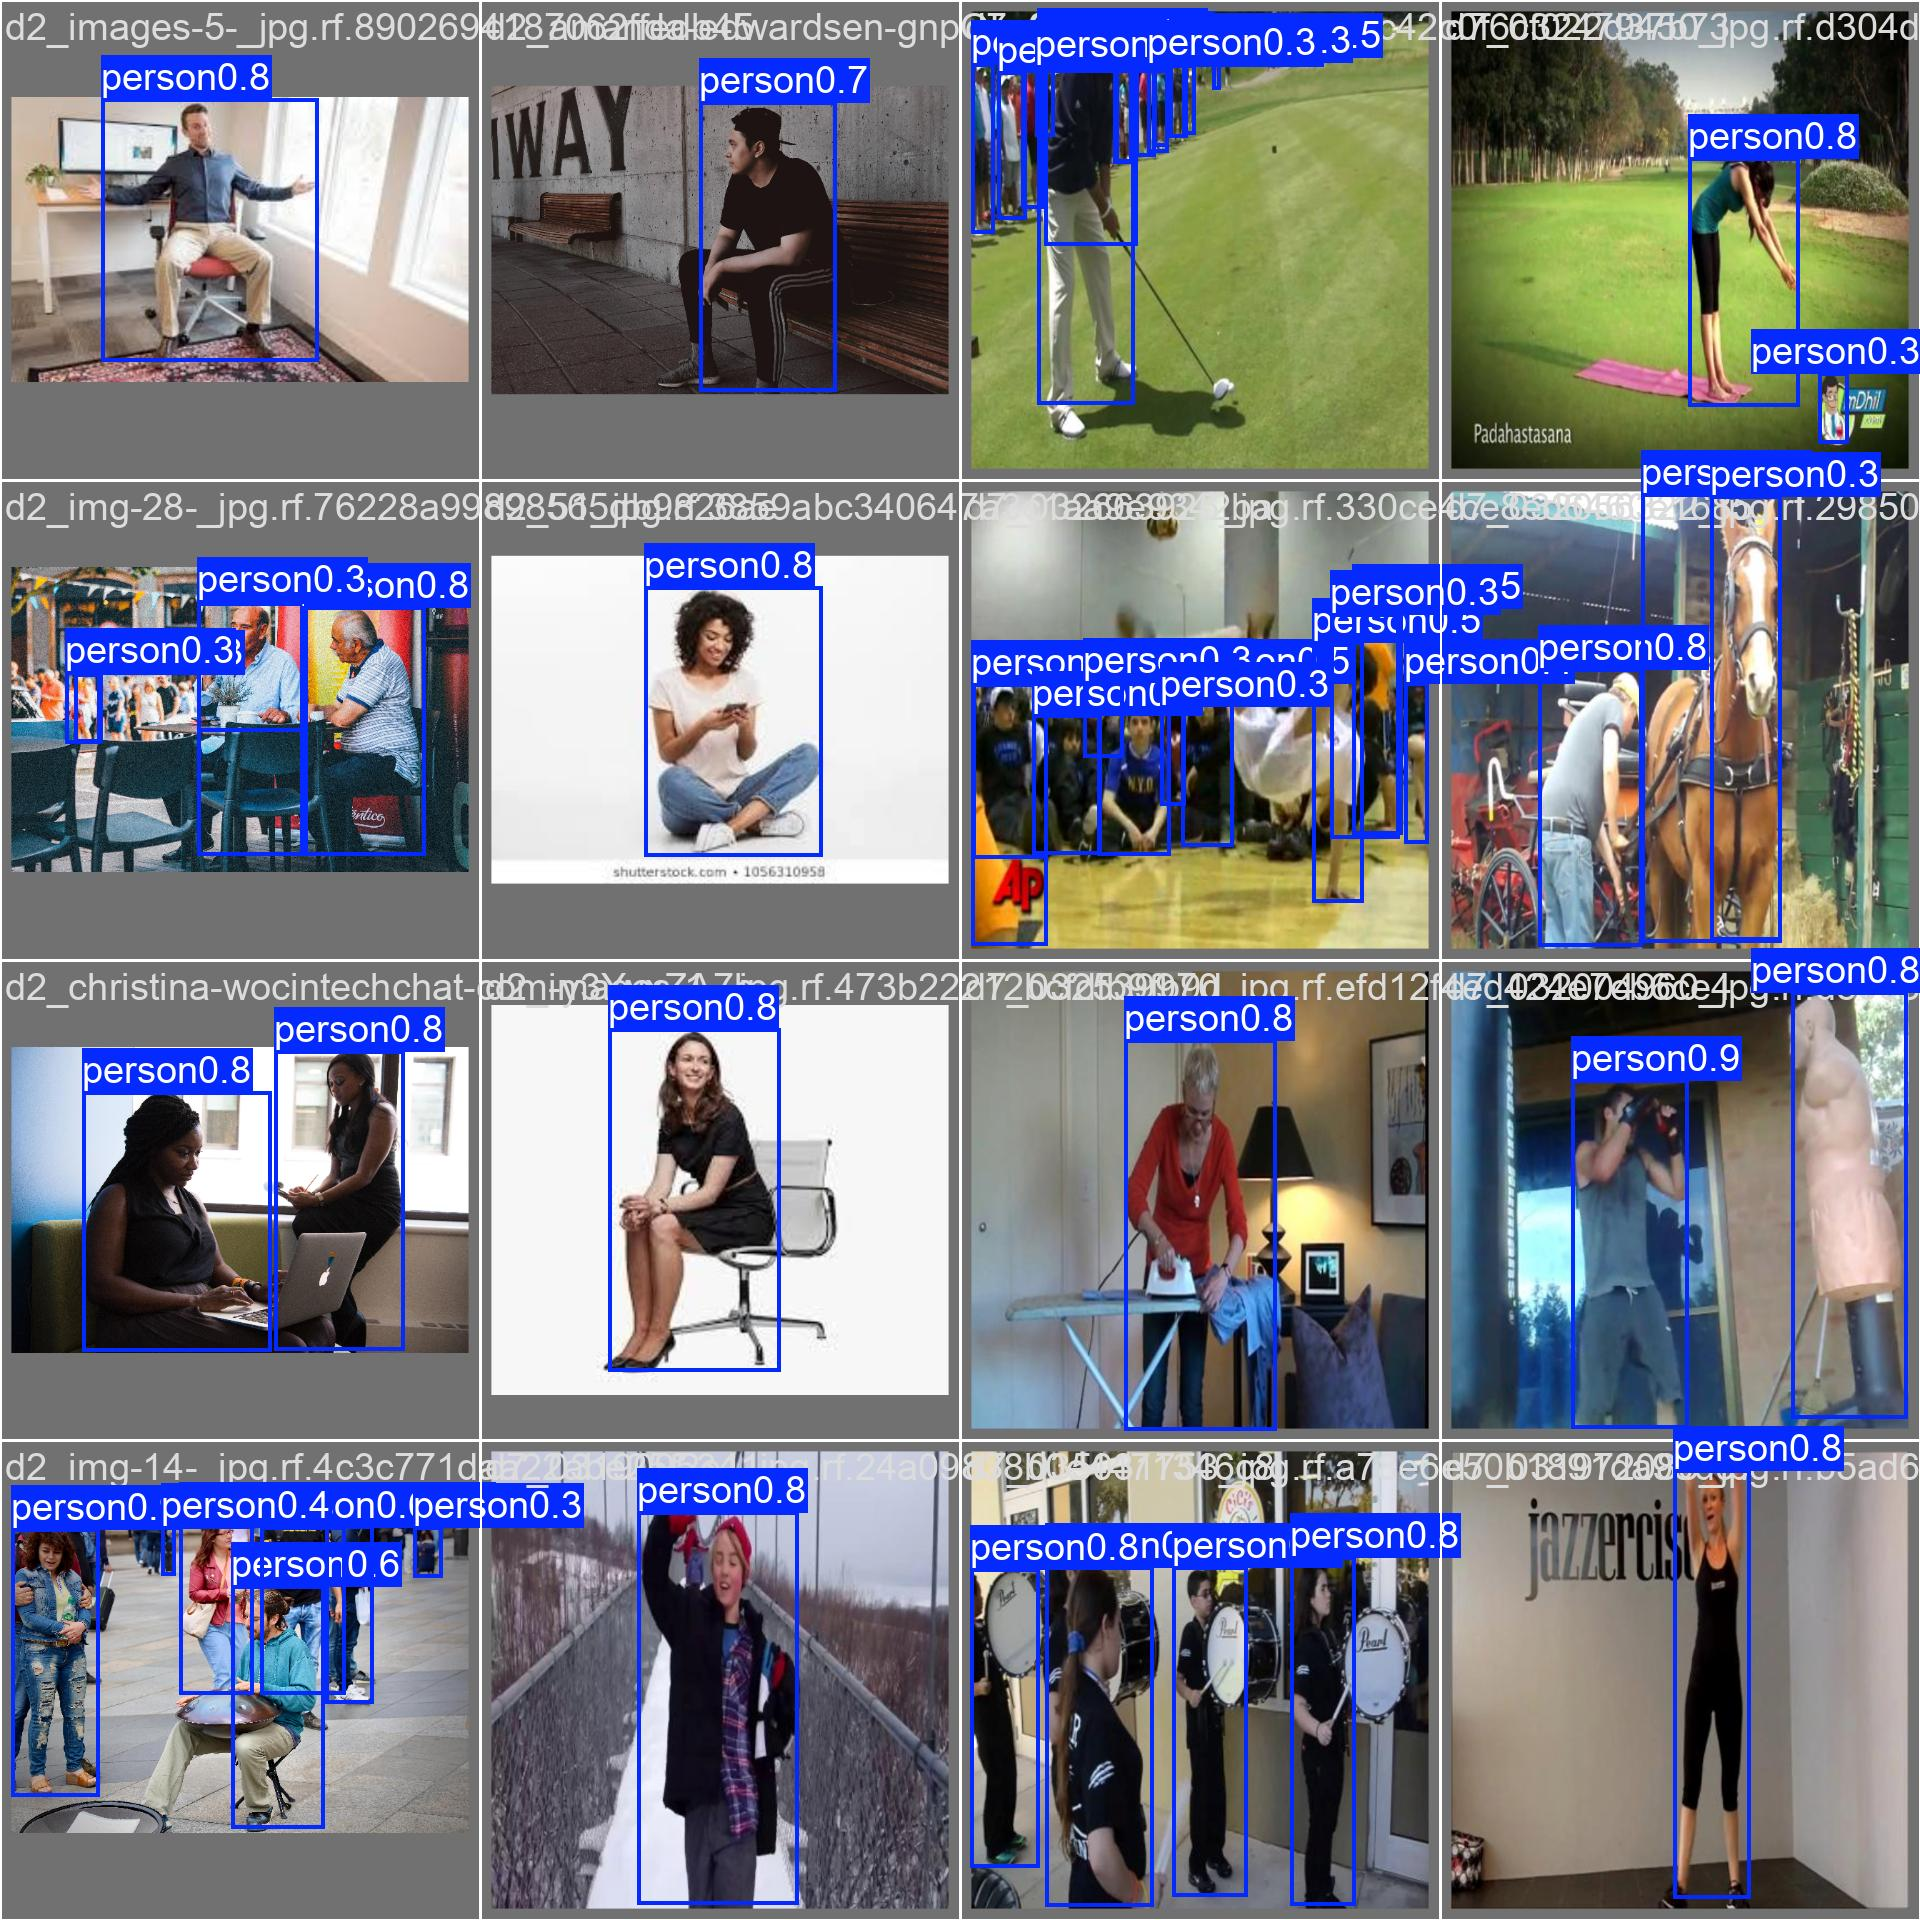

In [12]:
for filename in ['val_batch0_labels.jpg', 'val_batch0_pred.jpg']:
    image_path = RUN_DIR / filename
    if image_path.exists():
        print(filename)
        display(Image(filename=str(image_path), width=1000))

<h3 style="color:#111111; border-left:3px solid #111111; padding-left:8px;"> 4. 학습 그래프 확인 </h3>

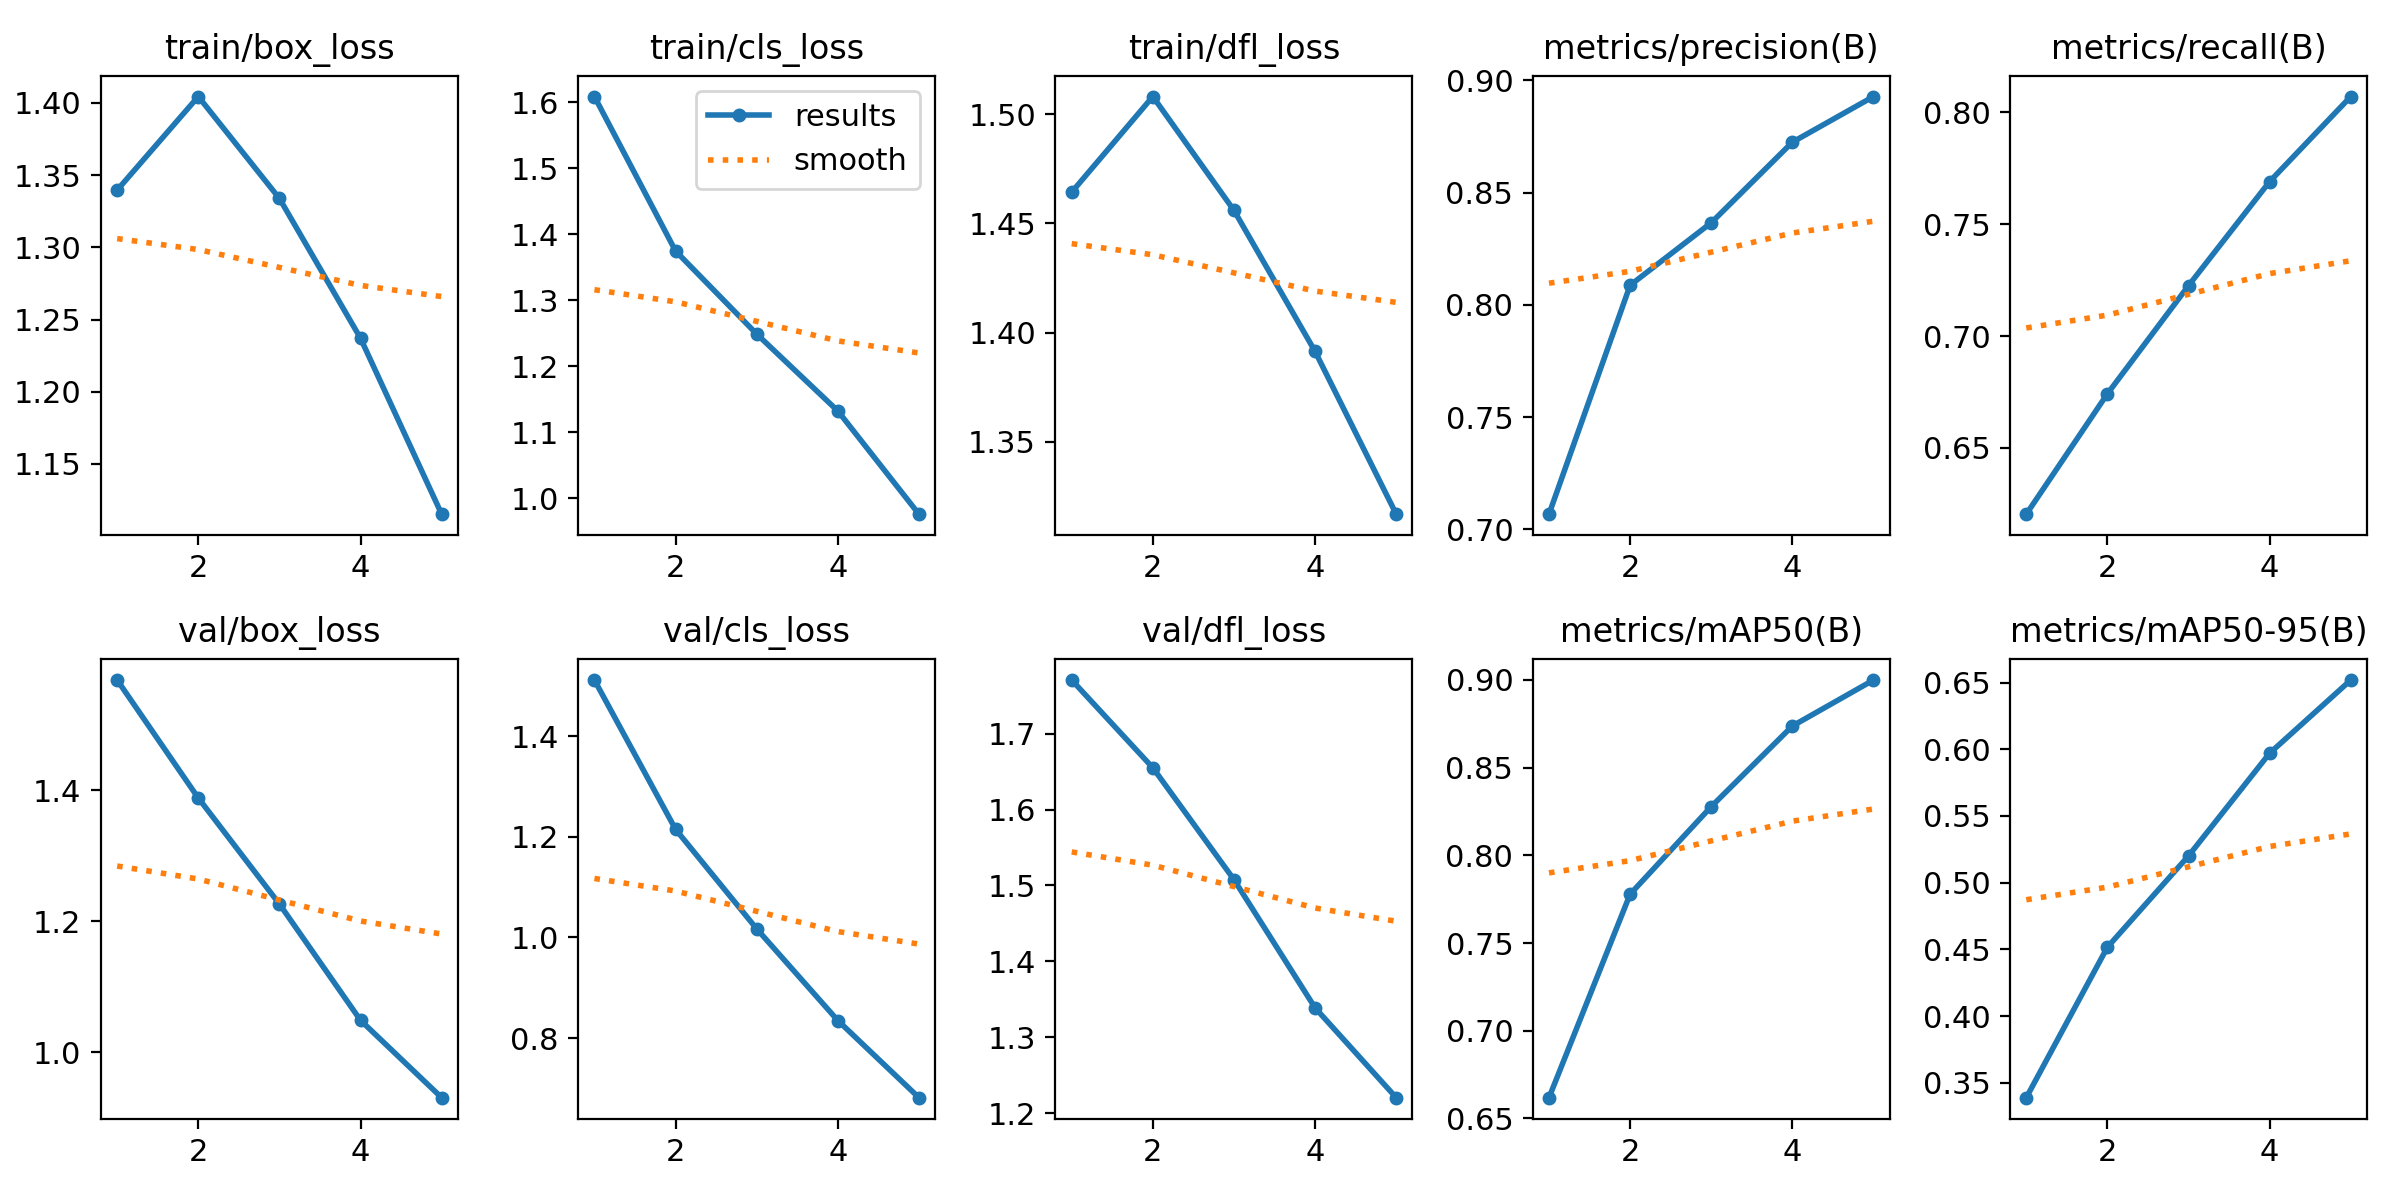

In [13]:
results_path = RUN_DIR / 'results.png'
if results_path.exists():
    display(Image(filename=str(results_path), width=1100))
else:
    print('results.png을 찾을 수 없습니다:', results_path)

<h3 style="color:#111111; border-left:3px solid #111111; padding-left:8px;"> 5. 혼동행렬 확인 </h3>

confusion_matrix.png


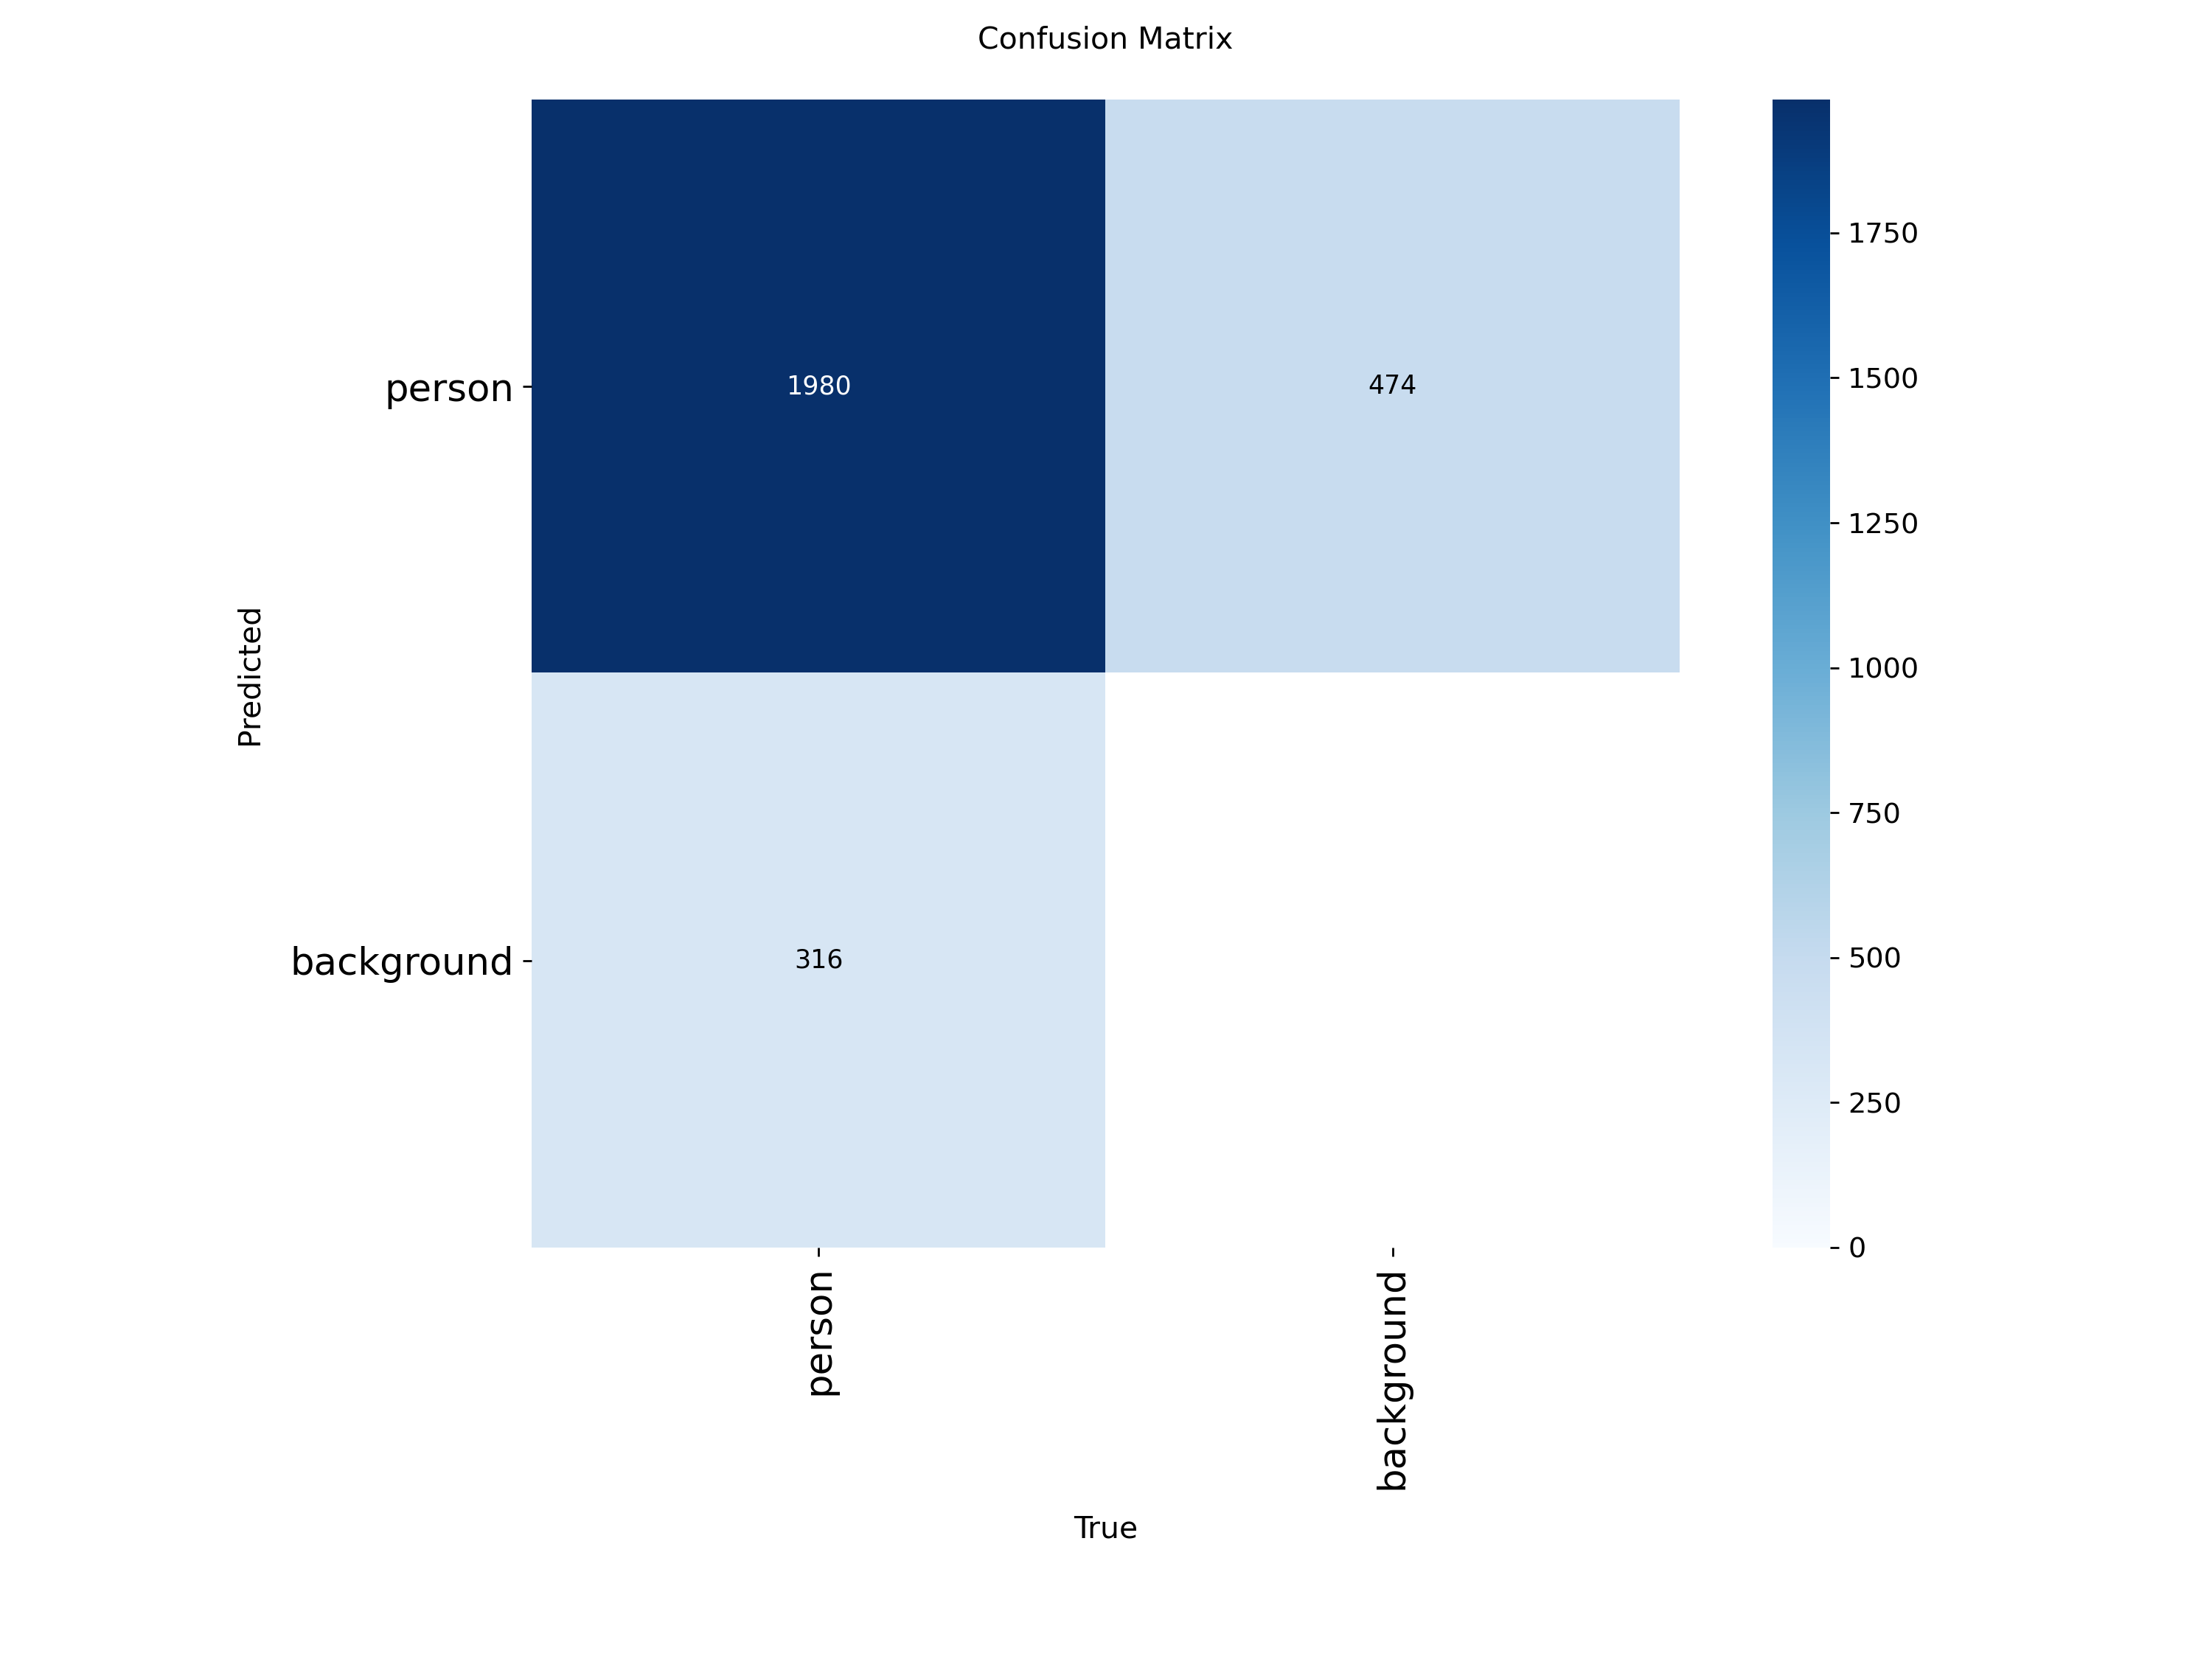

confusion_matrix_normalized.png


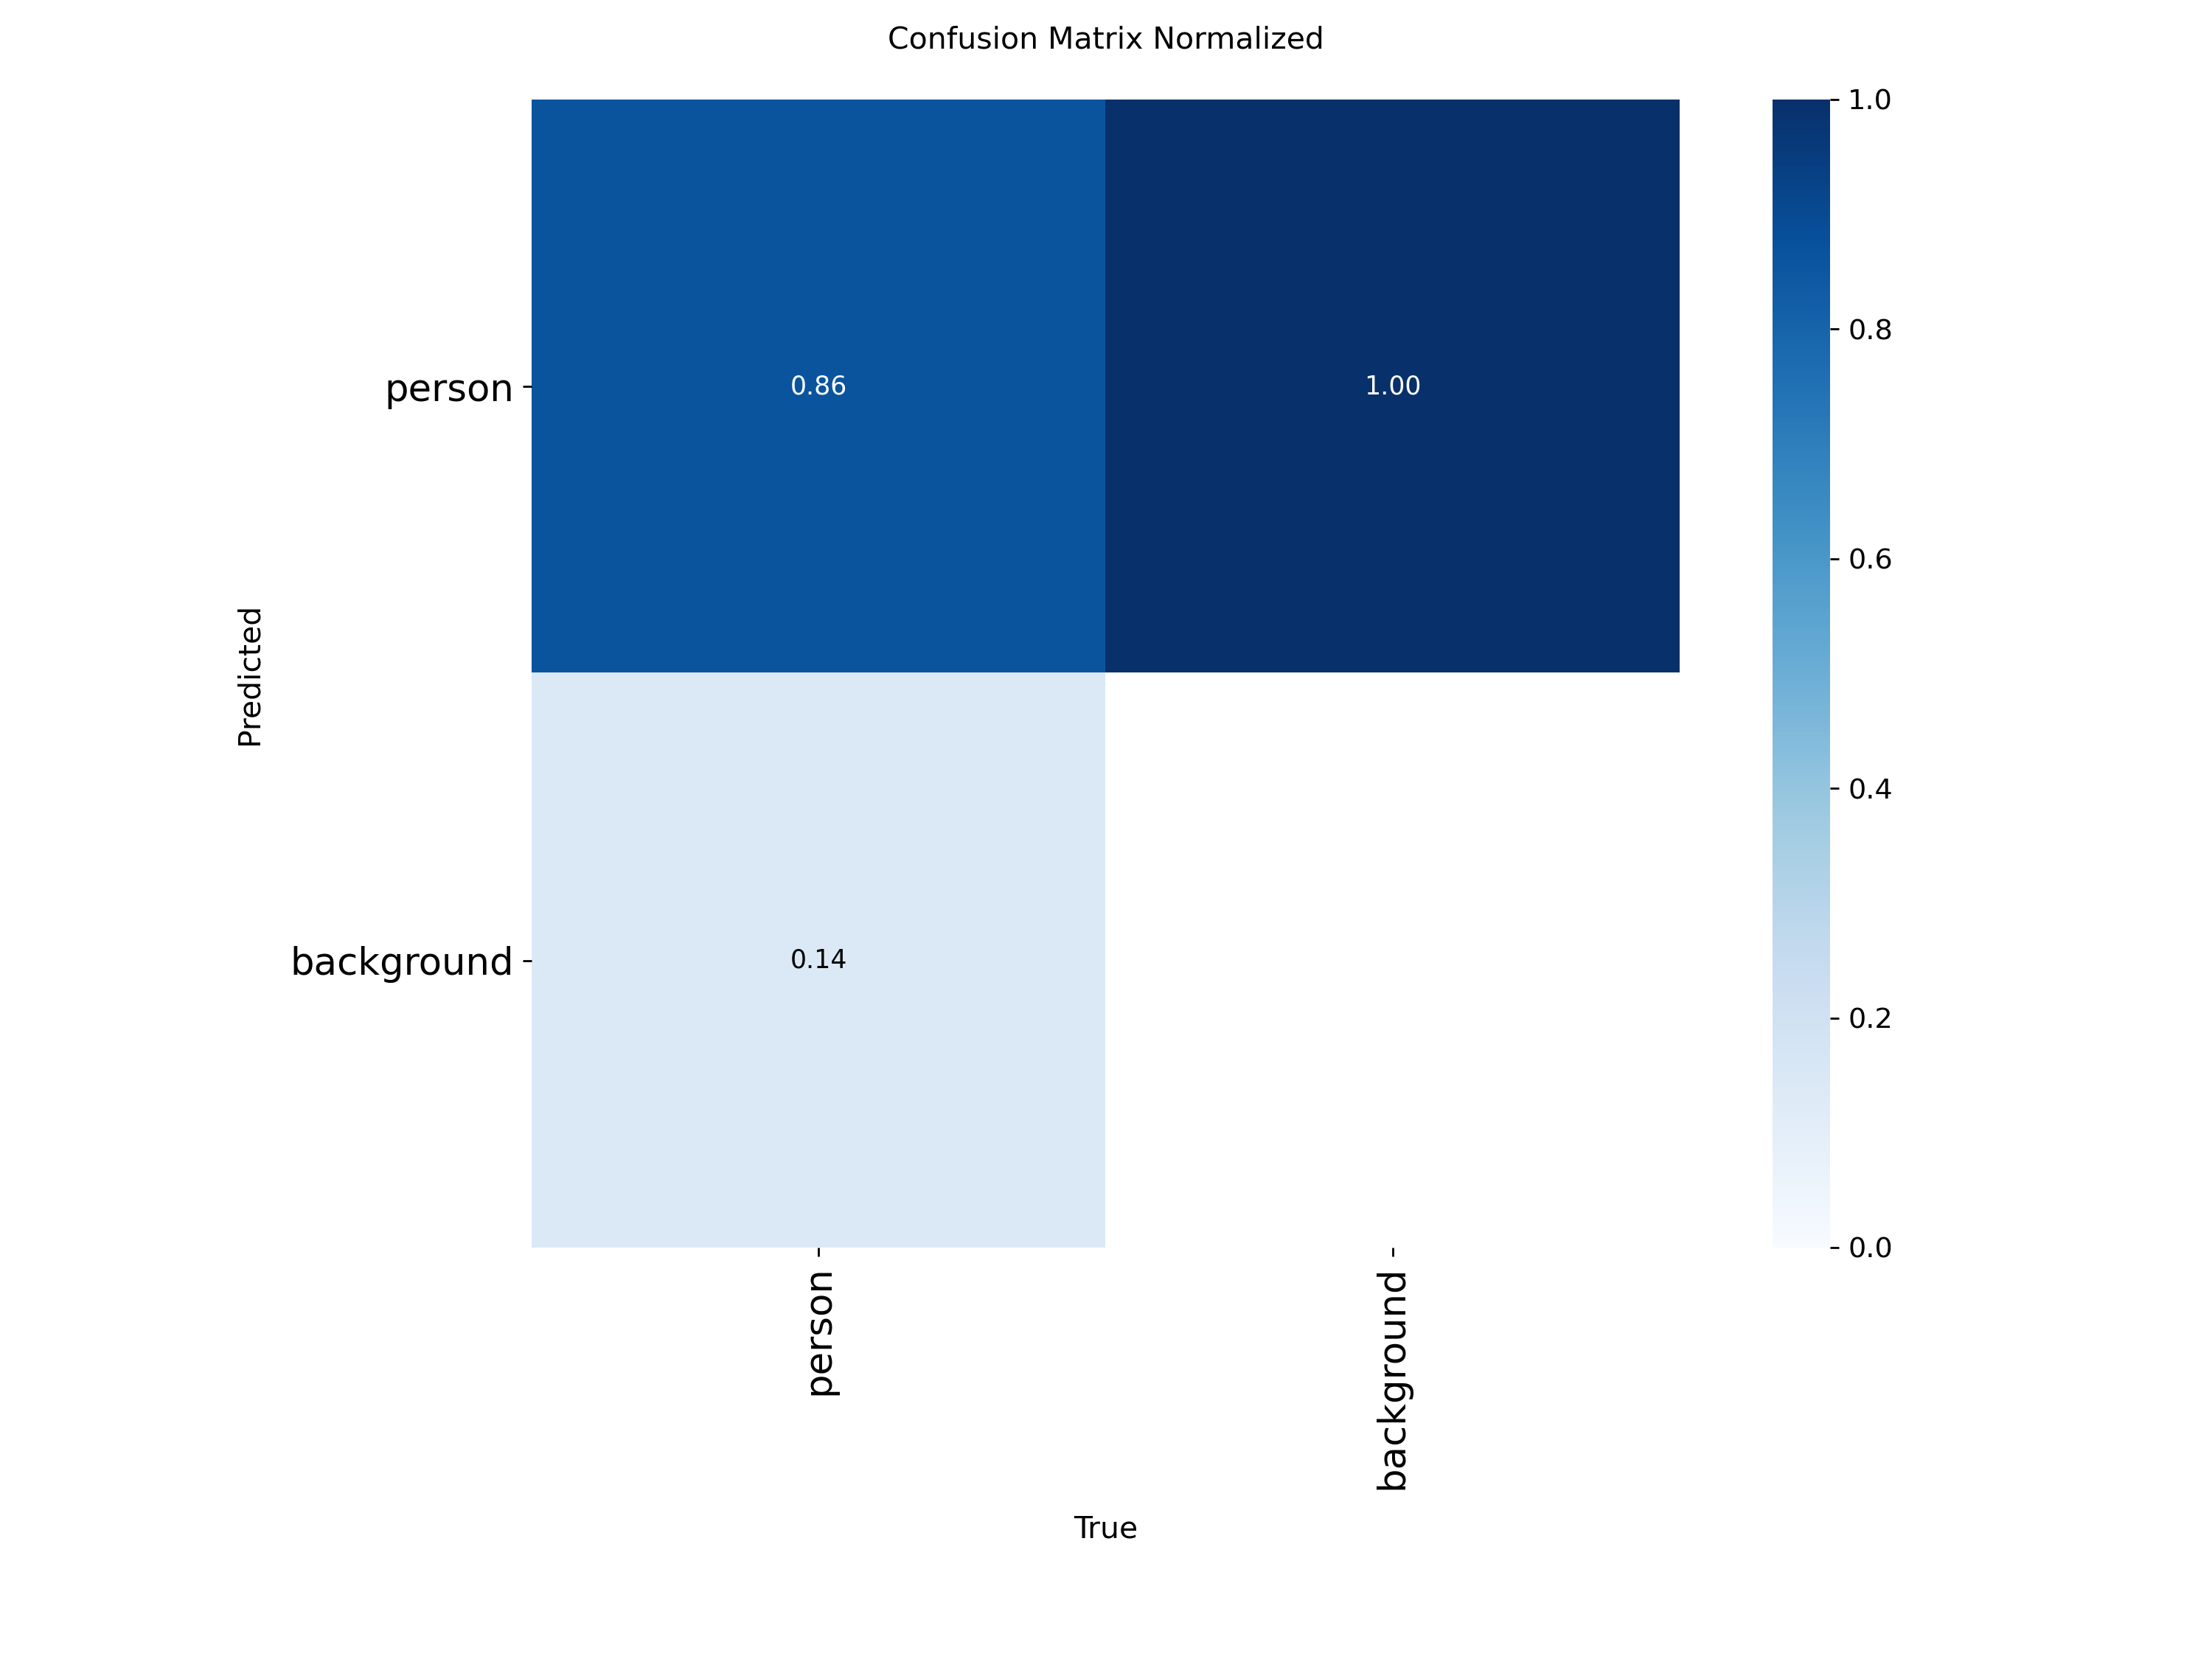

In [14]:
for filename in ['confusion_matrix.png', 'confusion_matrix_normalized.png']:
    image_path = RUN_DIR / filename
    if image_path.exists():
        print(filename)
        display(Image(filename=str(image_path), width=900))

<h3 style="color:#111111; border-left:3px solid #111111; padding-left:8px;"> 6. 성능 지표와 모델 파일 확인 </h3>

In [15]:
BEST_MODEL = RUN_DIR / 'weights' / 'best.pt'
LAST_MODEL = RUN_DIR / 'weights' / 'last.pt'
print('best.pt:', BEST_MODEL.exists(), BEST_MODEL)
print('last.pt:', LAST_MODEL.exists(), LAST_MODEL)

if not BEST_MODEL.is_file() or not LAST_MODEL.is_file():
    raise FileNotFoundError('시험 학습의 best.pt 또는 last.pt가 없습니다.')

best_model = YOLO(str(BEST_MODEL))
SMOKE_TEST_DIR = RUN_DIR / 'test_evaluation'
metrics = best_model.val(
    data=str(DATA_YAML),
    split='test',
    imgsz=640,
    device=DEVICE,
    plots=True,
    project=str(RUN_DIR),
    name=SMOKE_TEST_DIR.name,
    exist_ok=True,
)
print(f'Precision : {metrics.box.mp:.4f}')
print(f'Recall    : {metrics.box.mr:.4f}')
print(f'mAP50     : {metrics.box.map50:.4f}')
print(f'mAP50-95  : {metrics.box.map:.4f}')
print('시험 학습 Test 결과:', SMOKE_TEST_DIR)

best.pt: True /kaggle/working/wardy/ml/src/export/person_detector_smoke_test/weights/best.pt
last.pt: True /kaggle/working/wardy/ml/src/export/person_detector_smoke_test/weights/last.pt
Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 850.3±280.7 MB/s, size: 27.6 KB)
val: Scanning /kaggle/working/person_dataset/labels/test... 1178 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1178/1178 1.4Kit/s 0.9s
val: New cache created: /kaggle/working/person_dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 74/74 7.4it/s 10.0s
                   all       1178       2202      0.913      0.822      0.918      0.672
Speed: 1.0ms preprocess, 3.9ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /kaggle/working/wardy/ml/src/expor

<h3 style="color:#111111; border-left:3px solid #111111; padding-left:8px;"> 7. Test 이미지 사람 탐지 결과 확인 </h3>


image 1/1 /kaggle/working/person_dataset/images/test/d1_frame_0019_jpg.rf.1a8c838a3a2e74ca6c2bab4de4080746.jpg: 640x640 1 person, 7.8ms
Speed: 1.7ms preprocess, 7.8ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/wardy/ml/src/export/person_detector_smoke_test/prediction
테스트 이미지: /kaggle/working/person_dataset/images/test/d1_frame_0019_jpg.rf.1a8c838a3a2e74ca6c2bab4de4080746.jpg


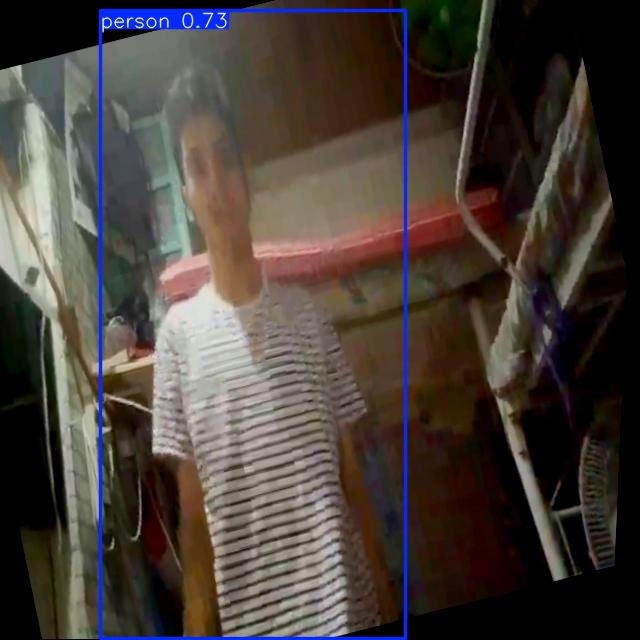

시험 학습 결과 및 백업 검증 완료: True
best.pt 크기: 5.2 MB
best.pt SHA-256: c127c3a11d367ffccf6527970c4fda8f4b7ea419204fdfc7aa9fdb7d1139ecb6
본 학습을 시작하기 전에 아래 두 파일을 PC에 다운로드하세요.


/kaggle/working/download/person_detector_smoke_best.pt

/kaggle/working/person_detector_smoke_test_results.zip

In [16]:
test_images = sorted((Path(DATASET_PATH) / 'images' / 'test').glob('*'))
if not test_images:
    raise FileNotFoundError('Test 이미지를 찾을 수 없습니다.')
prediction_results = best_model.predict(
    source=str(test_images[0]), conf=0.5, save=True, project=str(RUN_DIR), name='prediction', exist_ok=True
)
result_image = RUN_DIR / 'prediction' / test_images[0].name
print('테스트 이미지:', test_images[0])
if not result_image.exists():
    raise FileNotFoundError(f'시험 학습 예측 이미지를 찾을 수 없습니다: {result_image}')
display(Image(filename=str(result_image), width=1000))

# 시험 학습 전체 결과를 검증하고 PC 다운로드용으로 묶습니다.
import hashlib
import shutil
import zipfile
from IPython.display import display

SMOKE_DOWNLOAD_DIR = Path('/kaggle/working/download')
SMOKE_DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)
SMOKE_DOWNLOAD_BEST = SMOKE_DOWNLOAD_DIR / 'person_detector_smoke_best.pt'
shutil.copy2(BEST_MODEL, SMOKE_DOWNLOAD_BEST)

SMOKE_RESULT_ZIP = Path(shutil.make_archive(
    '/kaggle/working/person_detector_smoke_test_results',
    'zip',
    root_dir=RUN_DIR,
))
with zipfile.ZipFile(SMOKE_RESULT_ZIP, 'r') as zip_ref:
    bad_file = zip_ref.testzip()
if bad_file is not None:
    raise RuntimeError(f'시험 학습 ZIP이 손상되었습니다: {bad_file}')

smoke_sha256 = hashlib.sha256(SMOKE_DOWNLOAD_BEST.read_bytes()).hexdigest()
required_smoke_files = [
    BEST_MODEL,
    LAST_MODEL,
    RUN_DIR / 'results.csv',
    RUN_DIR / 'results.png',
    result_image,
    SMOKE_DOWNLOAD_BEST,
    SMOKE_RESULT_ZIP,
]
missing_smoke_files = [path for path in required_smoke_files if not path.is_file()]
if missing_smoke_files:
    raise FileNotFoundError(f'시험 학습 필수 결과가 없습니다: {missing_smoke_files}')

SMOKE_BACKUP_VERIFIED = True
print('시험 학습 결과 및 백업 검증 완료:', SMOKE_BACKUP_VERIFIED)
print(f'best.pt 크기: {SMOKE_DOWNLOAD_BEST.stat().st_size / 1024**2:.1f} MB')
print('best.pt SHA-256:', smoke_sha256)
print('본 학습을 시작하기 전에 Kaggle Output에서 아래 두 파일을 다운로드하세요.')
print(SMOKE_DOWNLOAD_BEST)
print(SMOKE_RESULT_ZIP)

<h2 style="color:#111111; border-left:5px solid #111111; padding-left:12px;"> 11. 본 학습 </h2>

In [17]:
from IPython.display import display
import hashlib
import shutil
import zipfile

MAIN_RUN_DIR = PROJECT_ROOT / 'ml/src/export/person_detector_training'

if not globals().get('SMOKE_BACKUP_VERIFIED', False):
    raise RuntimeError(
        '시험 학습 결과와 백업 검증이 완료되지 않았습니다. '
        '10번의 7. Test 이미지 사람 탐지 결과 확인 셀까지 실행하세요.'
    )

main_model = YOLO('yolo11n.pt')
main_results = main_model.train(
    data=str(DATA_YAML),
    epochs=50,
    imgsz=640,
    batch=16,
    device=DEVICE,
    workers=2,
    patience=10,
    save_period=5,
    project=str(MAIN_RUN_DIR.parent),
    name=MAIN_RUN_DIR.name,
    exist_ok=True,
    seed=42,
    plots=True,
)

# 학습 종료 직후 모델 가중치를 다운로드 폴더에 복사합니다.
BEST_PT = MAIN_RUN_DIR / 'weights' / 'best.pt'
LAST_PT = MAIN_RUN_DIR / 'weights' / 'last.pt'
DOWNLOAD_DIR = Path('/kaggle/working/download')
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

if not BEST_PT.is_file():
    raise FileNotFoundError(f'학습 결과 best.pt가 없습니다: {BEST_PT}')

DOWNLOAD_BEST_PT = DOWNLOAD_DIR / 'person_detector_best.pt'
DOWNLOAD_LAST_PT = DOWNLOAD_DIR / 'person_detector_last.pt'
shutil.copy2(BEST_PT, DOWNLOAD_BEST_PT)
if LAST_PT.is_file():
    shutil.copy2(LAST_PT, DOWNLOAD_LAST_PT)

main_sha256 = hashlib.sha256(DOWNLOAD_BEST_PT.read_bytes()).hexdigest()
required_main_files = [BEST_PT, LAST_PT, DOWNLOAD_BEST_PT, DOWNLOAD_LAST_PT]
missing_main_files = [path for path in required_main_files if not path.is_file()]
if missing_main_files:
    raise FileNotFoundError(f'본 학습 필수 결과가 없습니다: {missing_main_files}')

print('본 학습 모델 백업 검증 완료')
print(f'best.pt 크기: {DOWNLOAD_BEST_PT.stat().st_size / 1024**2:.1f} MB')
print('best.pt SHA-256:', main_sha256)
print('Kaggle Output에서 아래 모델 파일을 다운로드할 수 있습니다.')
print(DOWNLOAD_BEST_PT)
print(DOWNLOAD_LAST_PT)

Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/person_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=person_detector_train

/kaggle/working/download/person_detector_best.pt

/kaggle/working/download/person_detector_last.pt

/kaggle/working/person_detector_training_results.zip

<h2 style="color:#111111; border-left:5px solid #111111; padding-left:12px;"> 12. 본 학습 결과 확인 </h2>

<h3 style="color:#111111; border-left:3px solid #111111; padding-left:8px;"> 1. 결과 폴더와 생성 파일 확인 </h3>

In [18]:
print('본 학습 결과 폴더:', MAIN_RUN_DIR)
print('폴더 존재:', MAIN_RUN_DIR.exists())
if MAIN_RUN_DIR.exists():
    for item in sorted(MAIN_RUN_DIR.iterdir()):
        print(item.name)

본 학습 결과 폴더: /kaggle/working/wardy/ml/src/export/person_detector_training
폴더 존재: True
BoxF1_curve.png
BoxPR_curve.png
BoxP_curve.png
BoxR_curve.png
args.yaml
confusion_matrix.png
confusion_matrix_normalized.png
labels.jpg
results.csv
results.png
train_batch0.jpg
train_batch1.jpg
train_batch2.jpg
train_batch23280.jpg
train_batch23281.jpg
train_batch23282.jpg
val_batch0_labels.jpg
val_batch0_pred.jpg
val_batch1_labels.jpg
val_batch1_pred.jpg
val_batch2_labels.jpg
val_batch2_pred.jpg
weights


<h3 style="color:#111111; border-left:3px solid #111111; padding-left:8px;"> 2. 학습 이미지와 정답 라벨 확인 </h3>

train_batch0.jpg


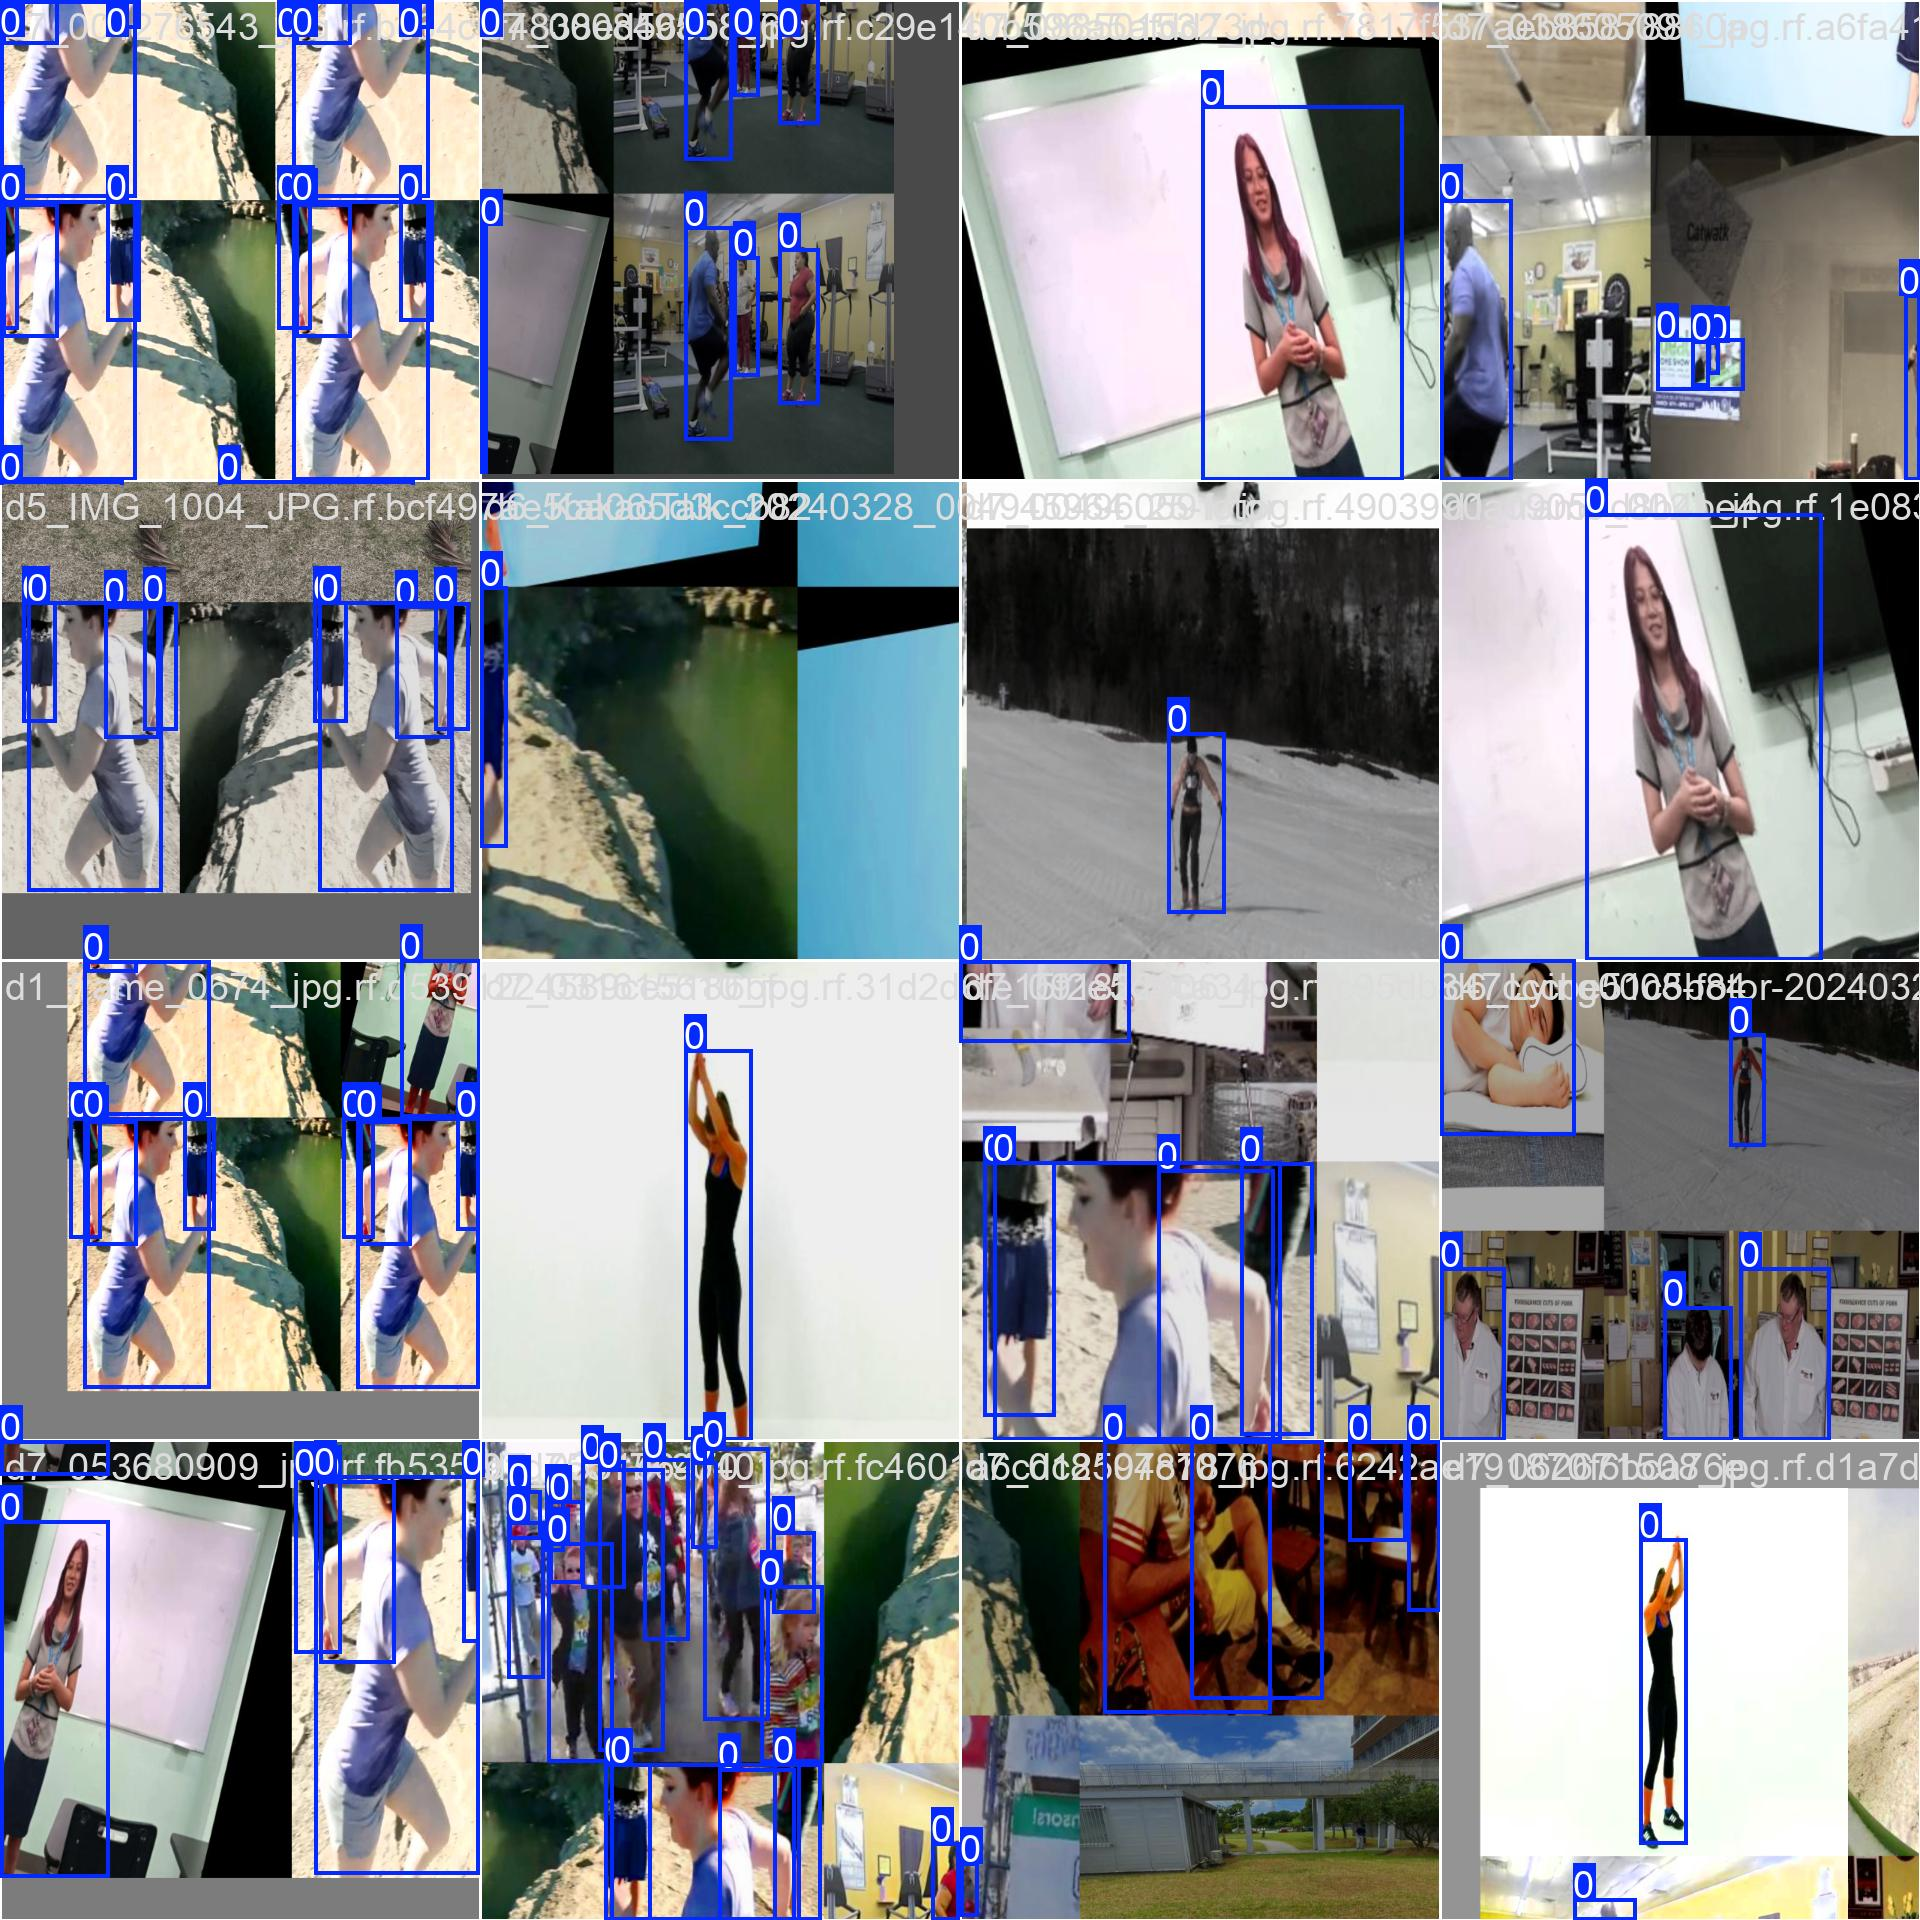

train_batch1.jpg


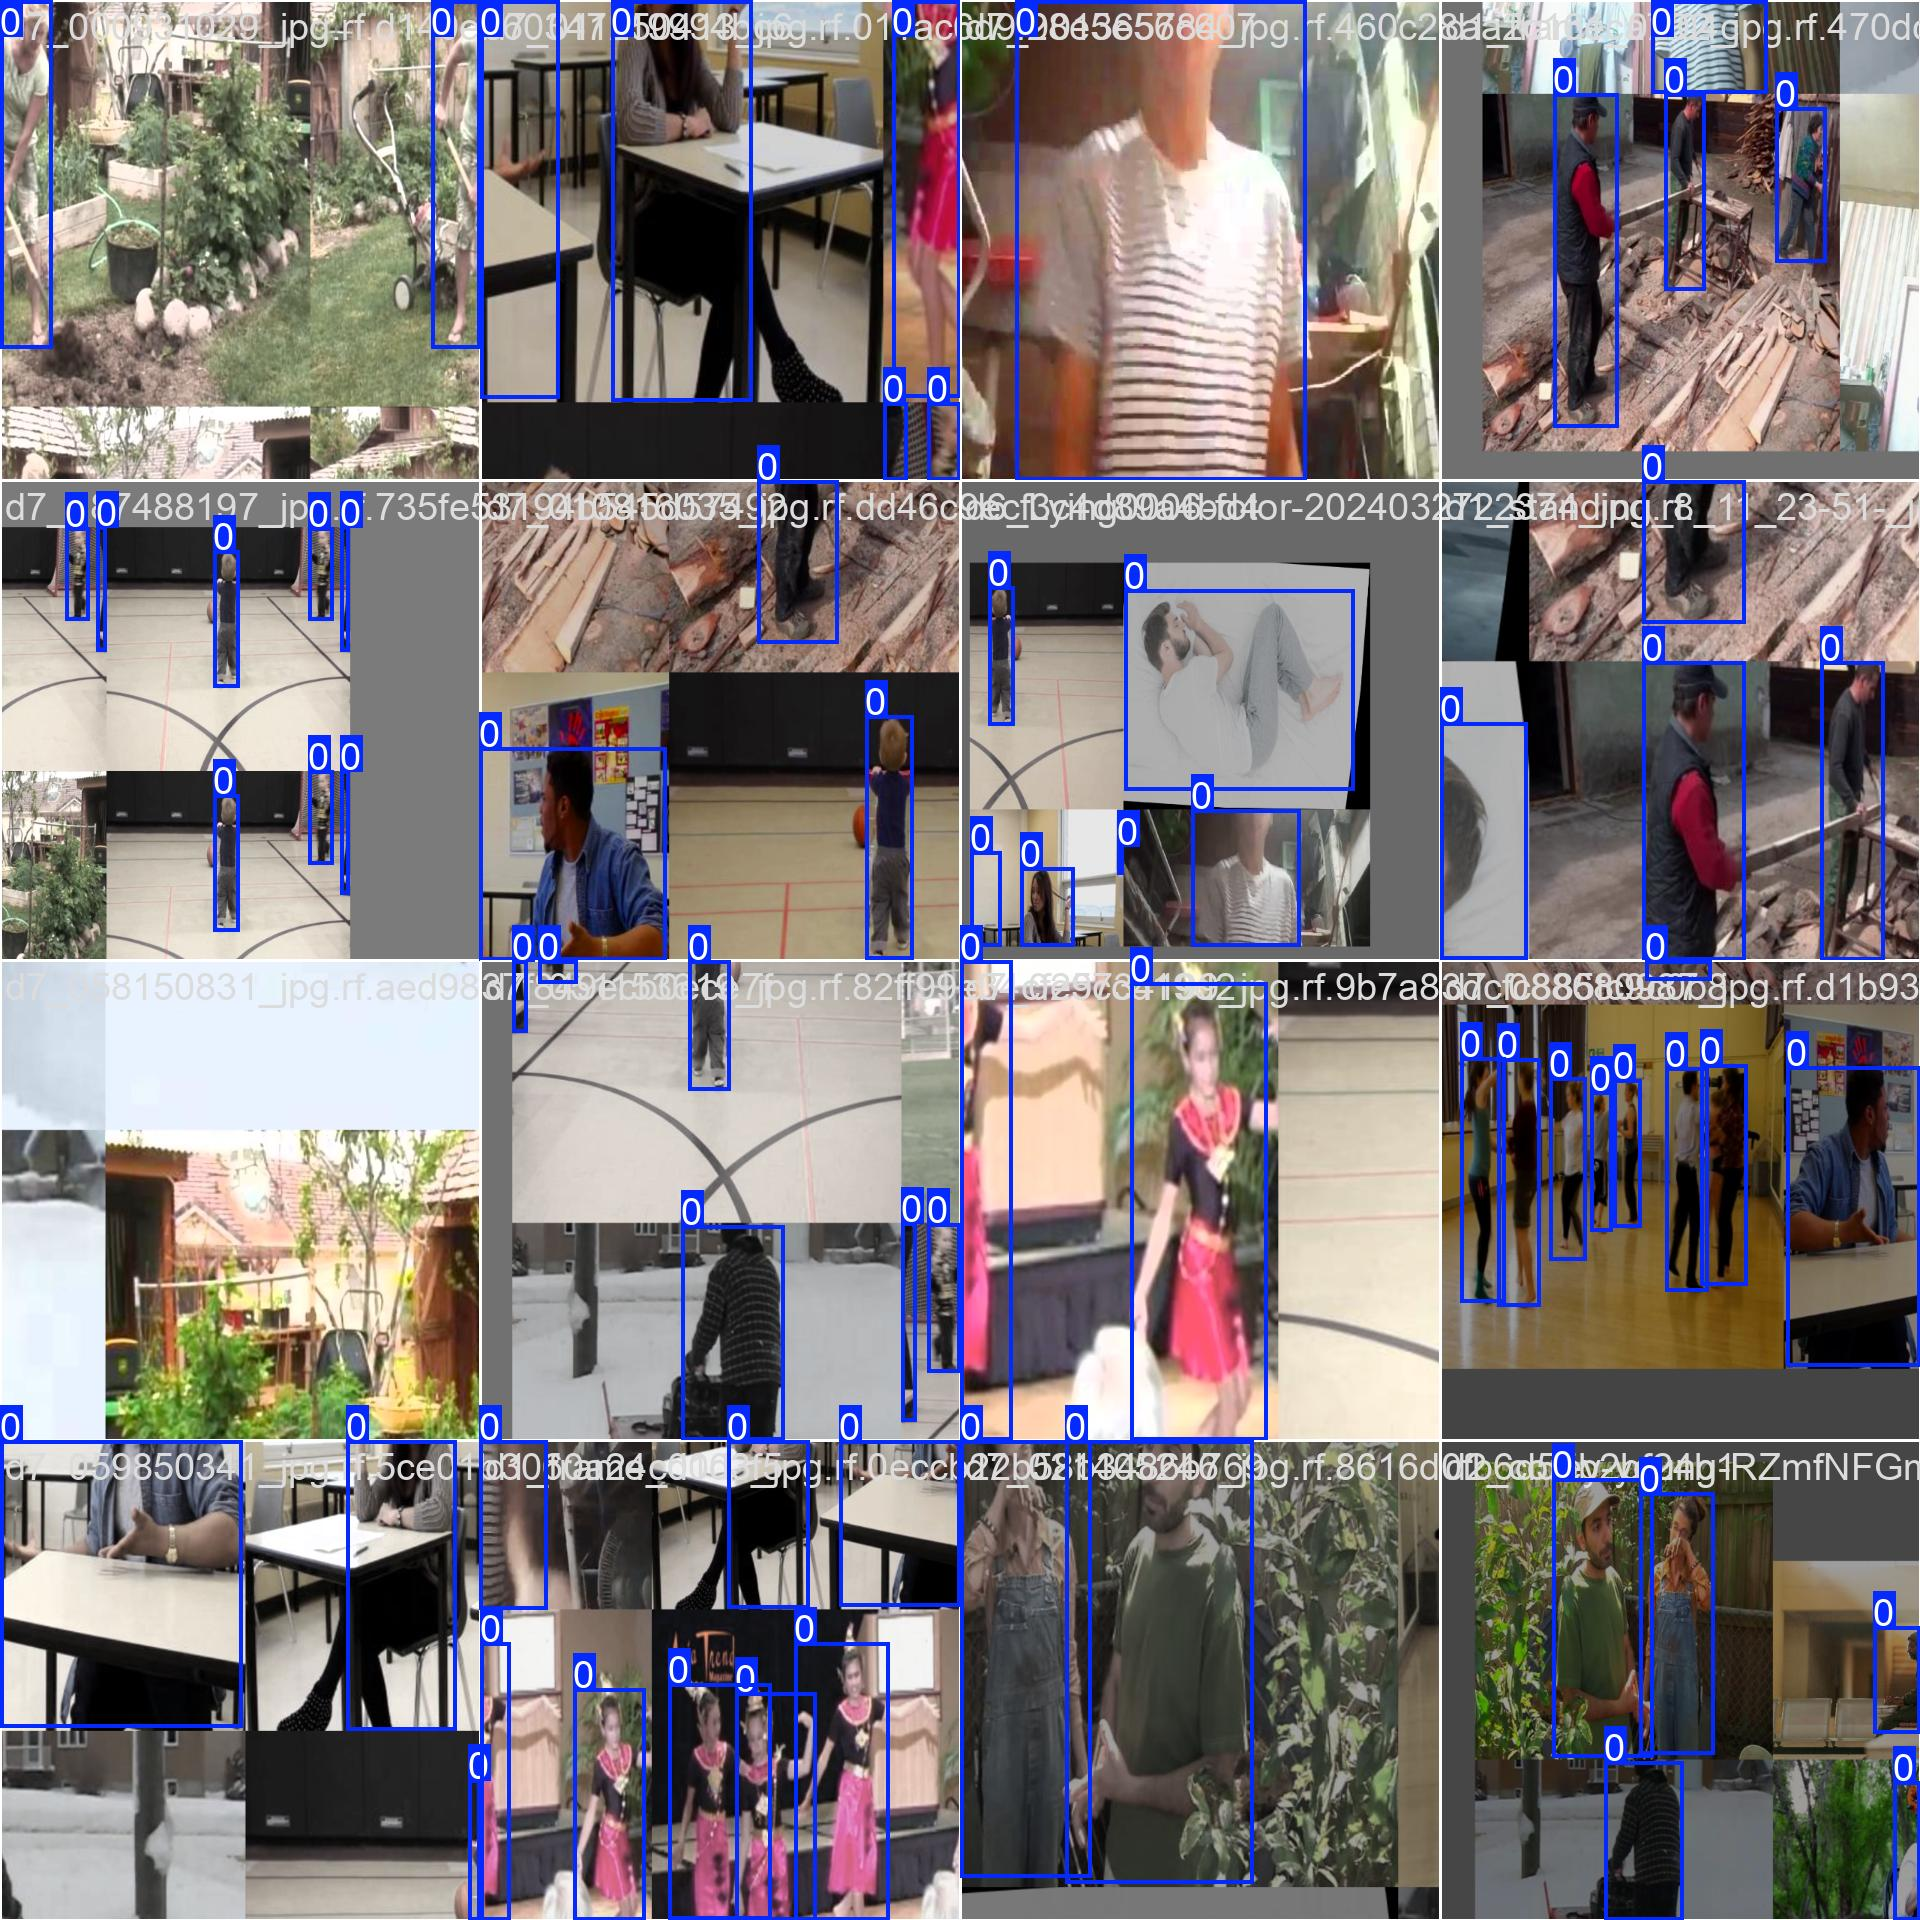

train_batch2.jpg


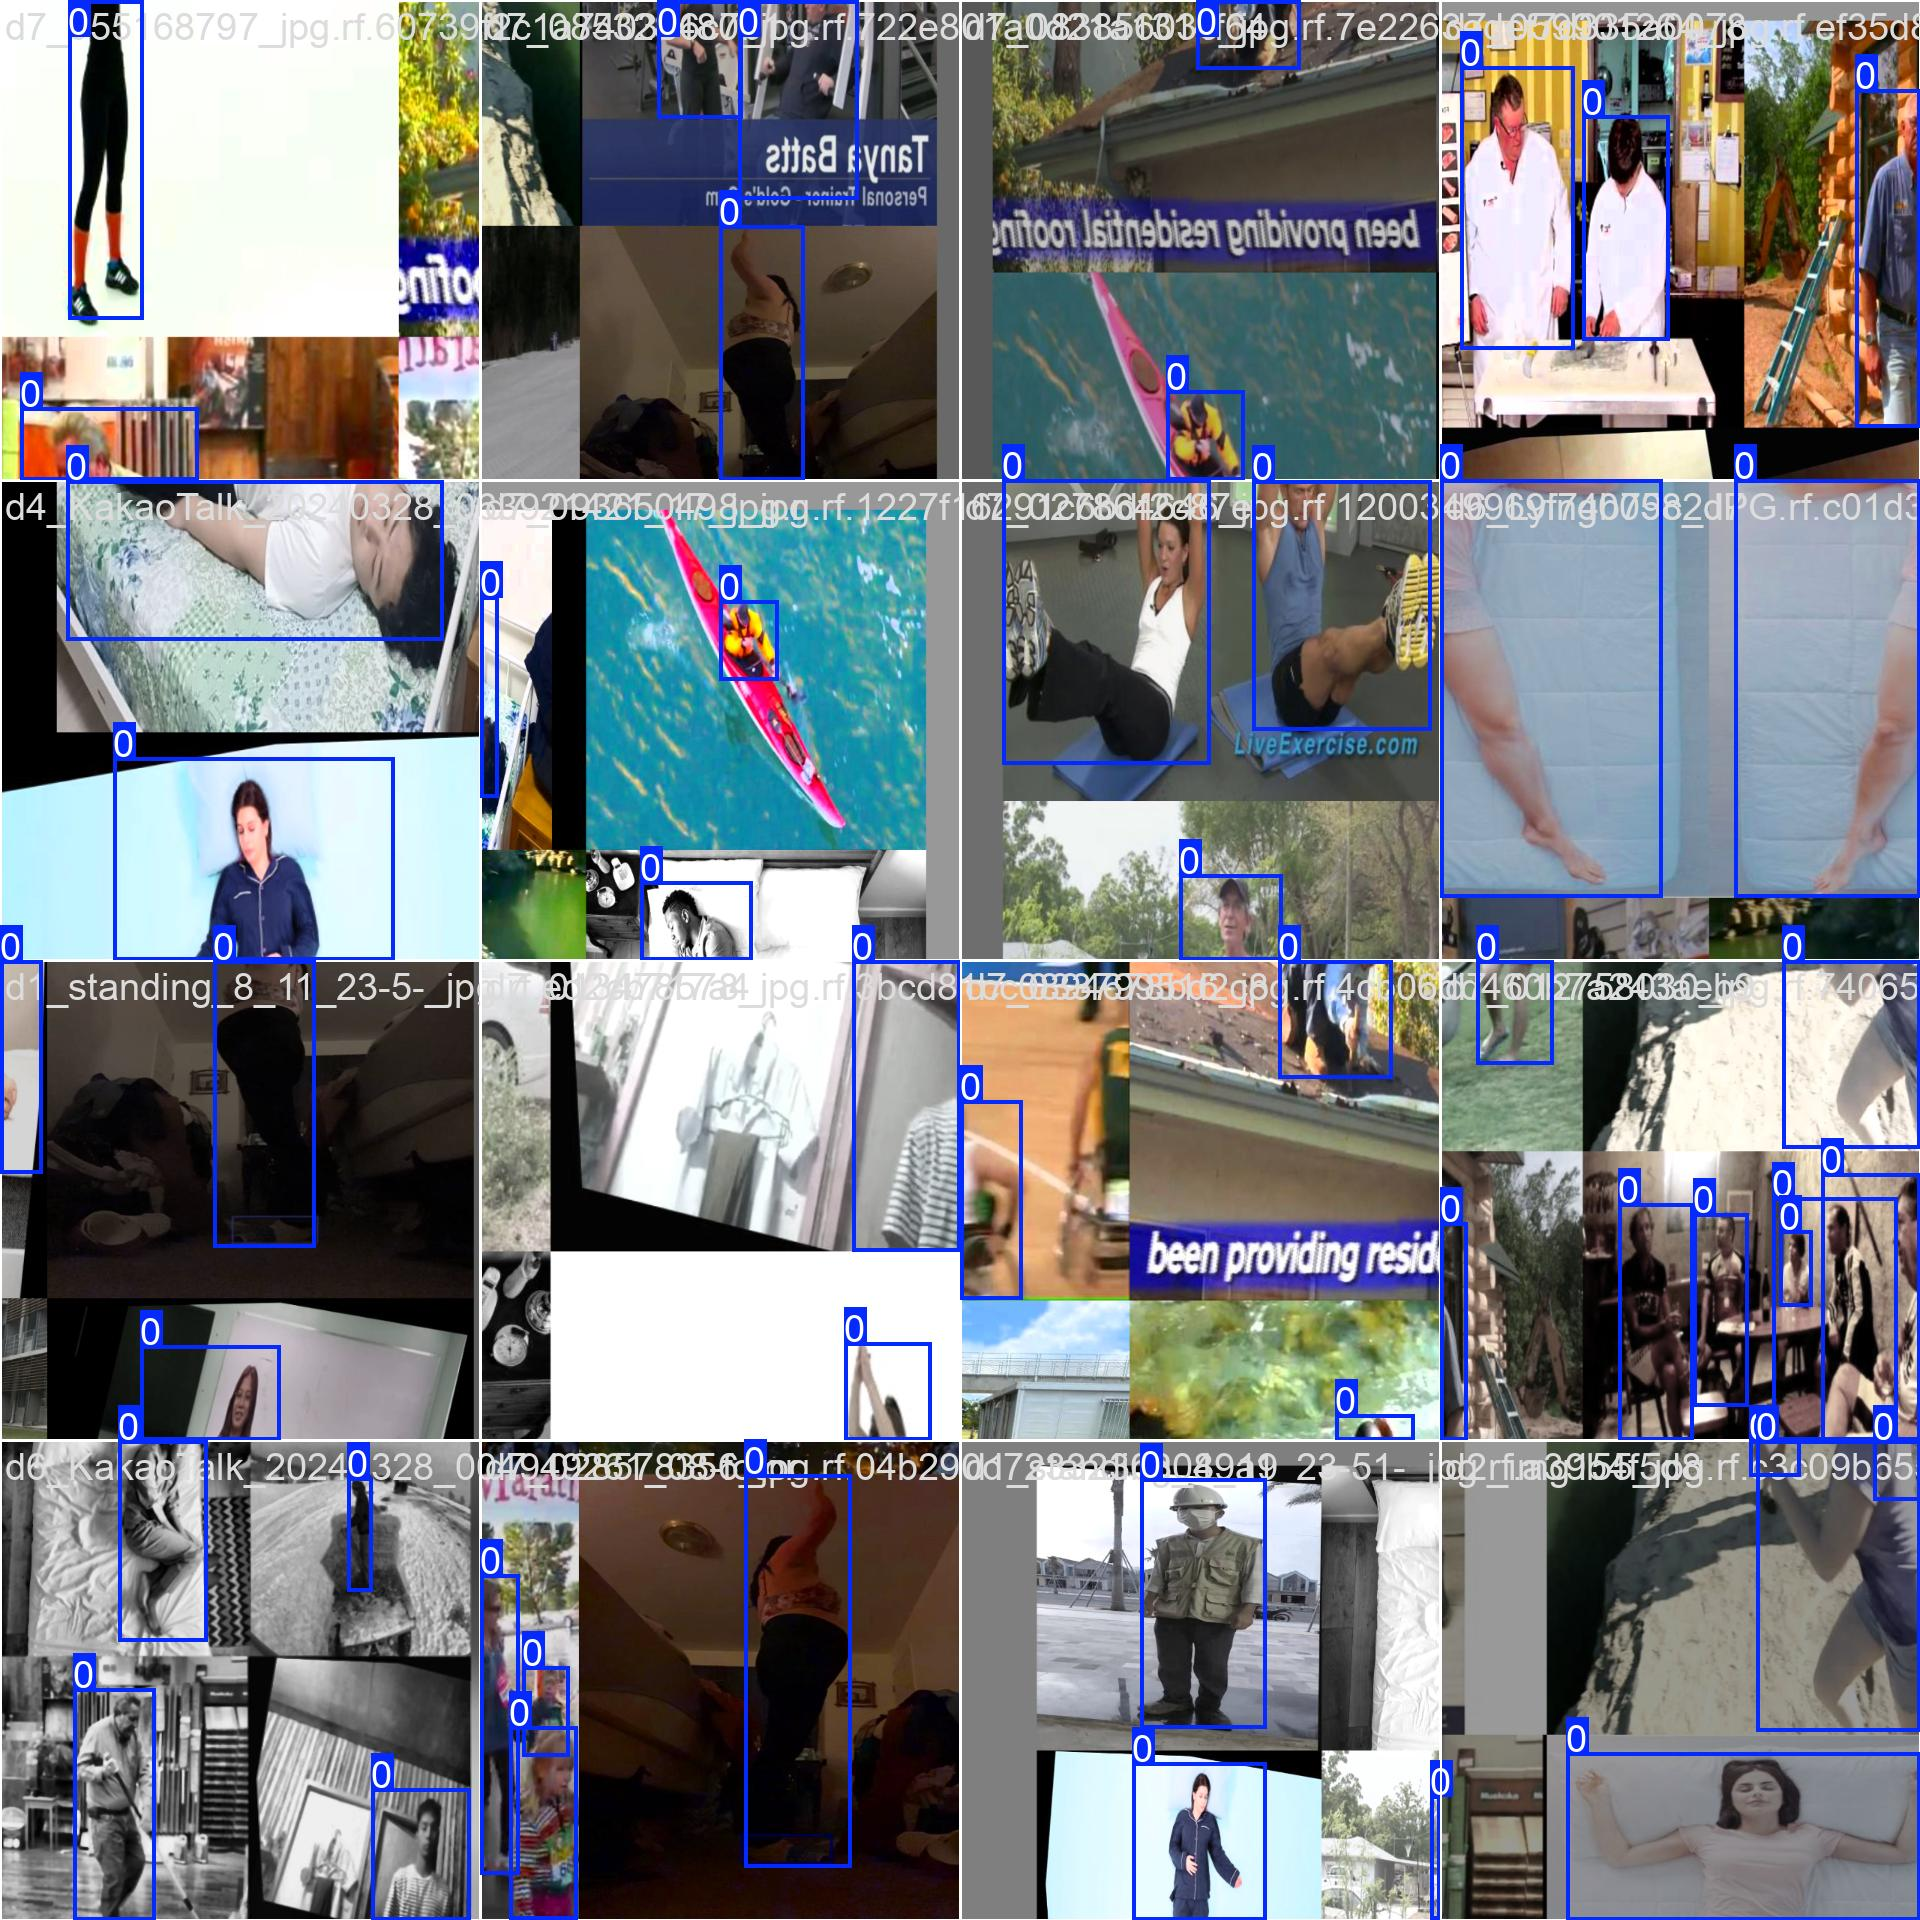

In [19]:
for filename in ['train_batch0.jpg', 'train_batch1.jpg', 'train_batch2.jpg']:
    image_path = MAIN_RUN_DIR / filename
    if image_path.exists():
        print(filename)
        display(Image(filename=str(image_path), width=1000))

<h3 style="color:#111111; border-left:3px solid #111111; padding-left:8px;"> 3. 검증 정답과 모델 예측 비교 </h3>

val_batch0_labels.jpg


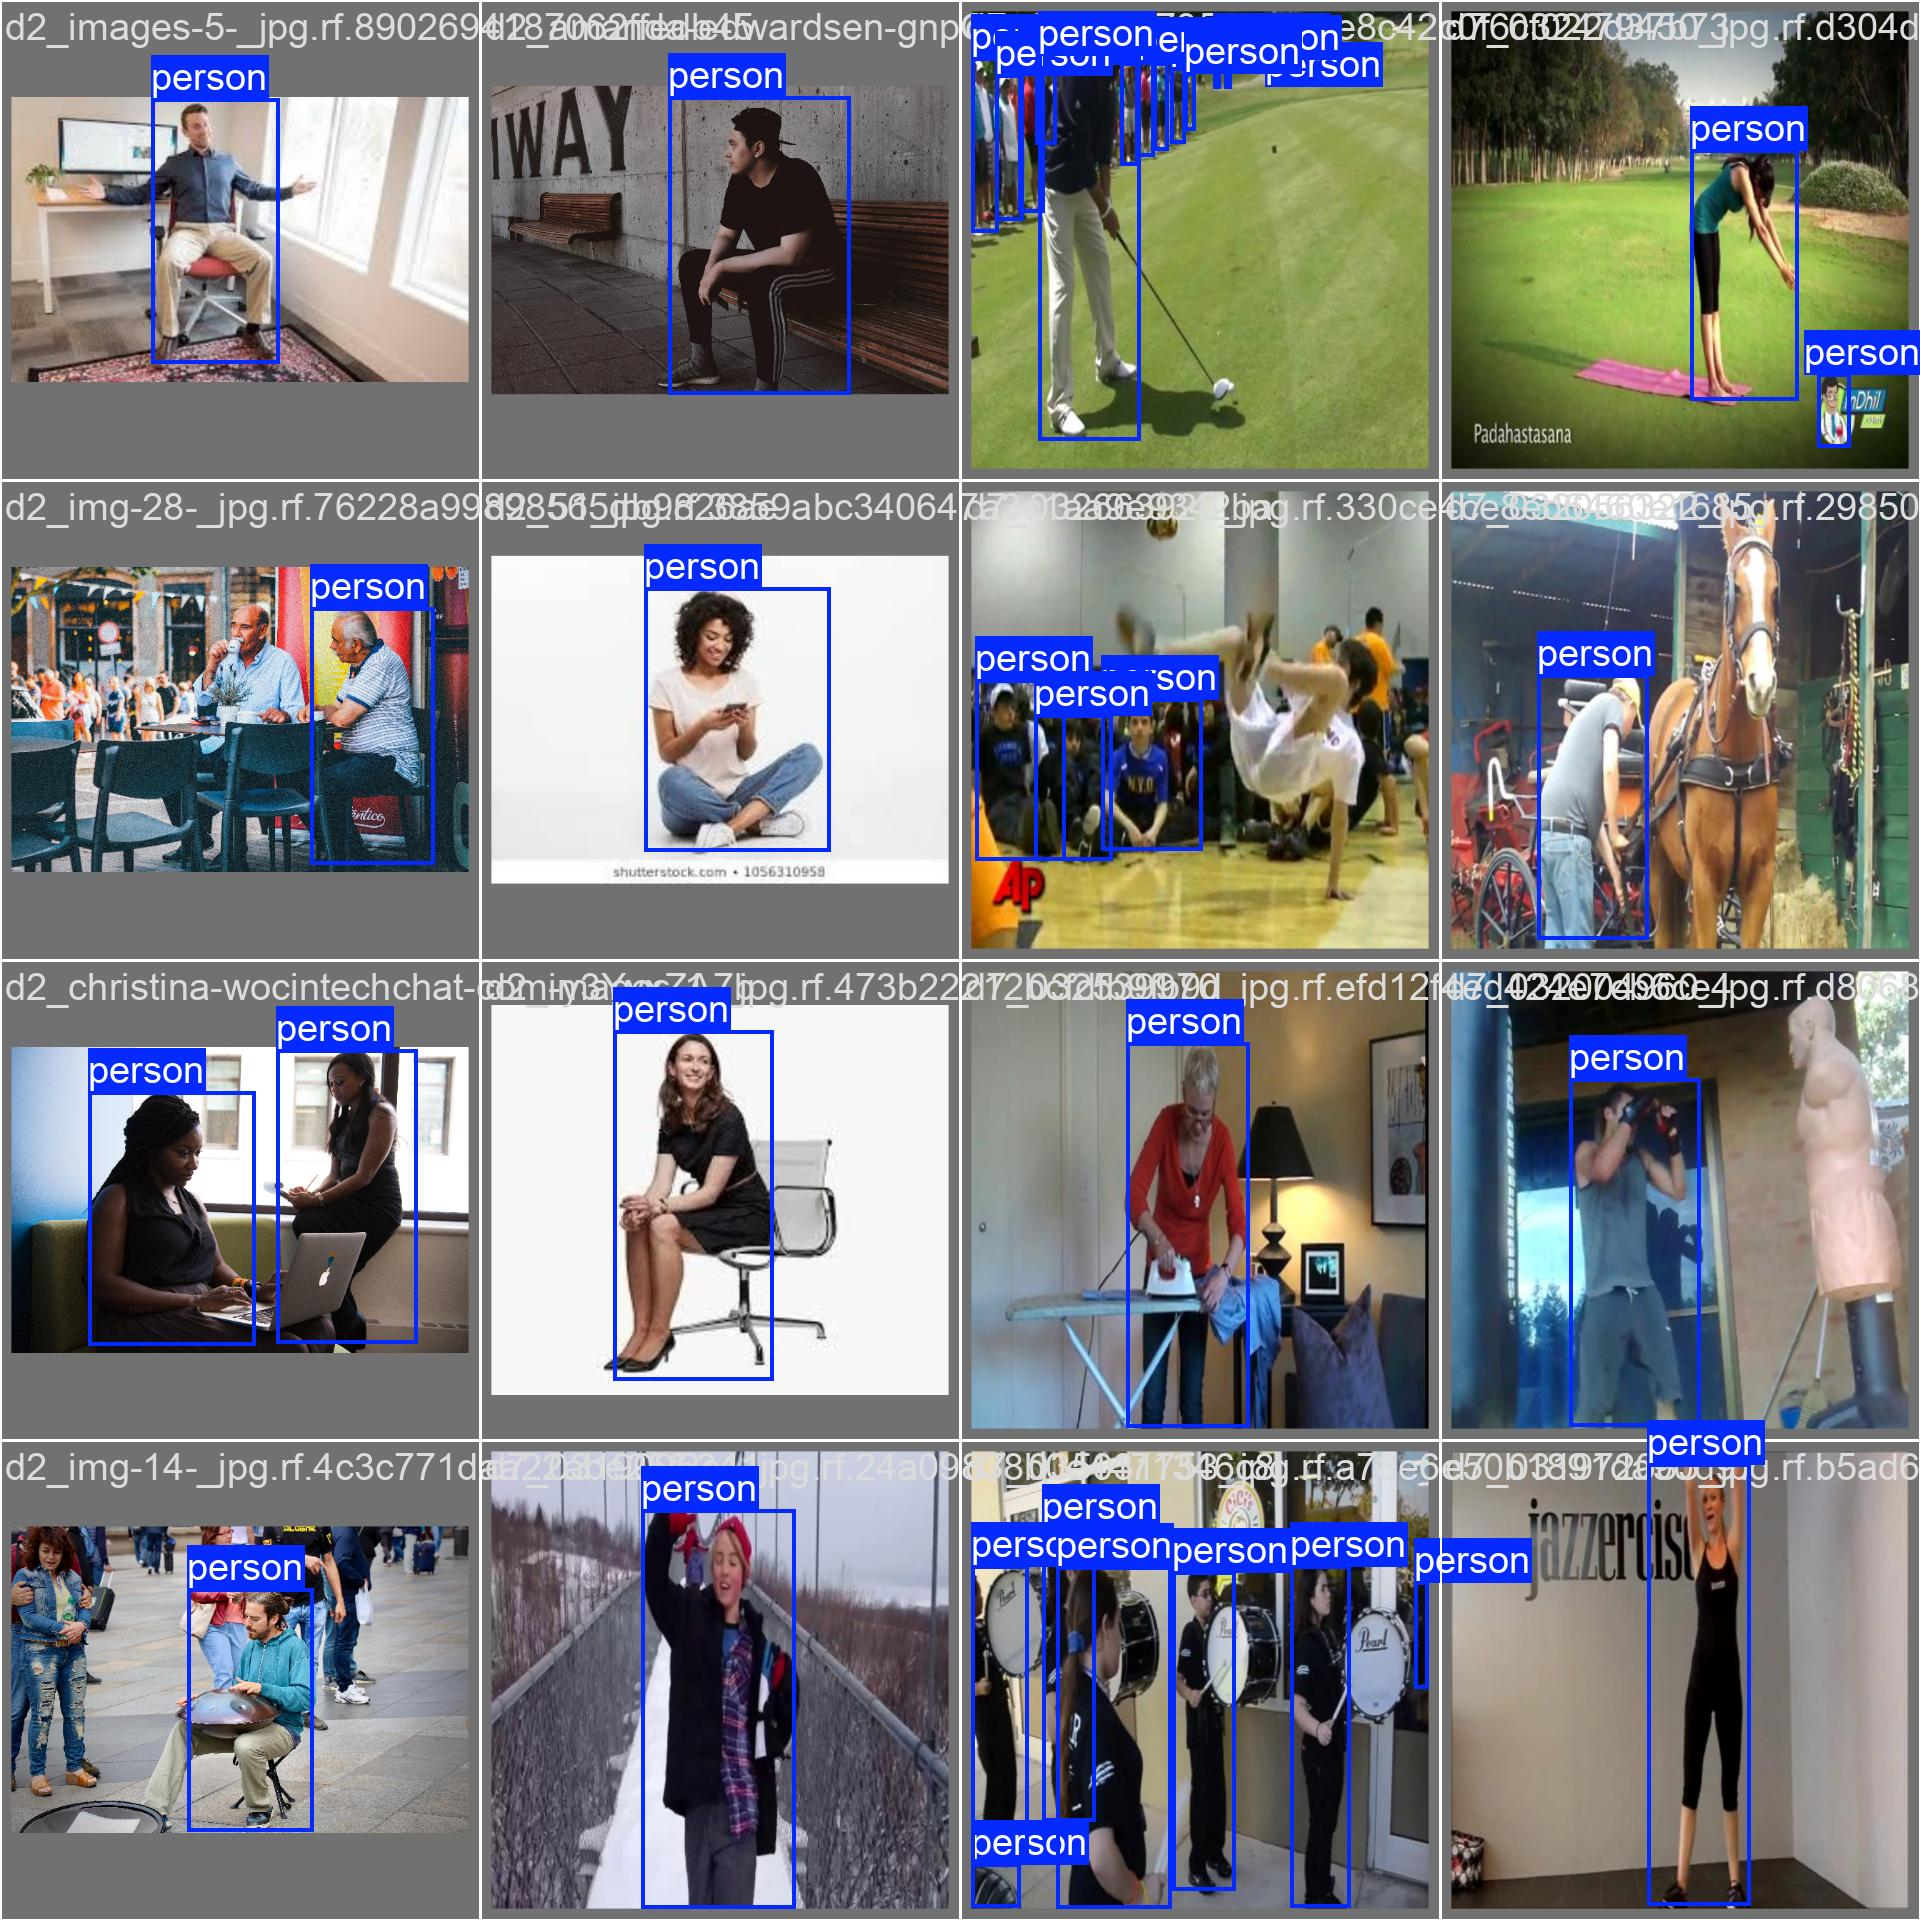

val_batch0_pred.jpg


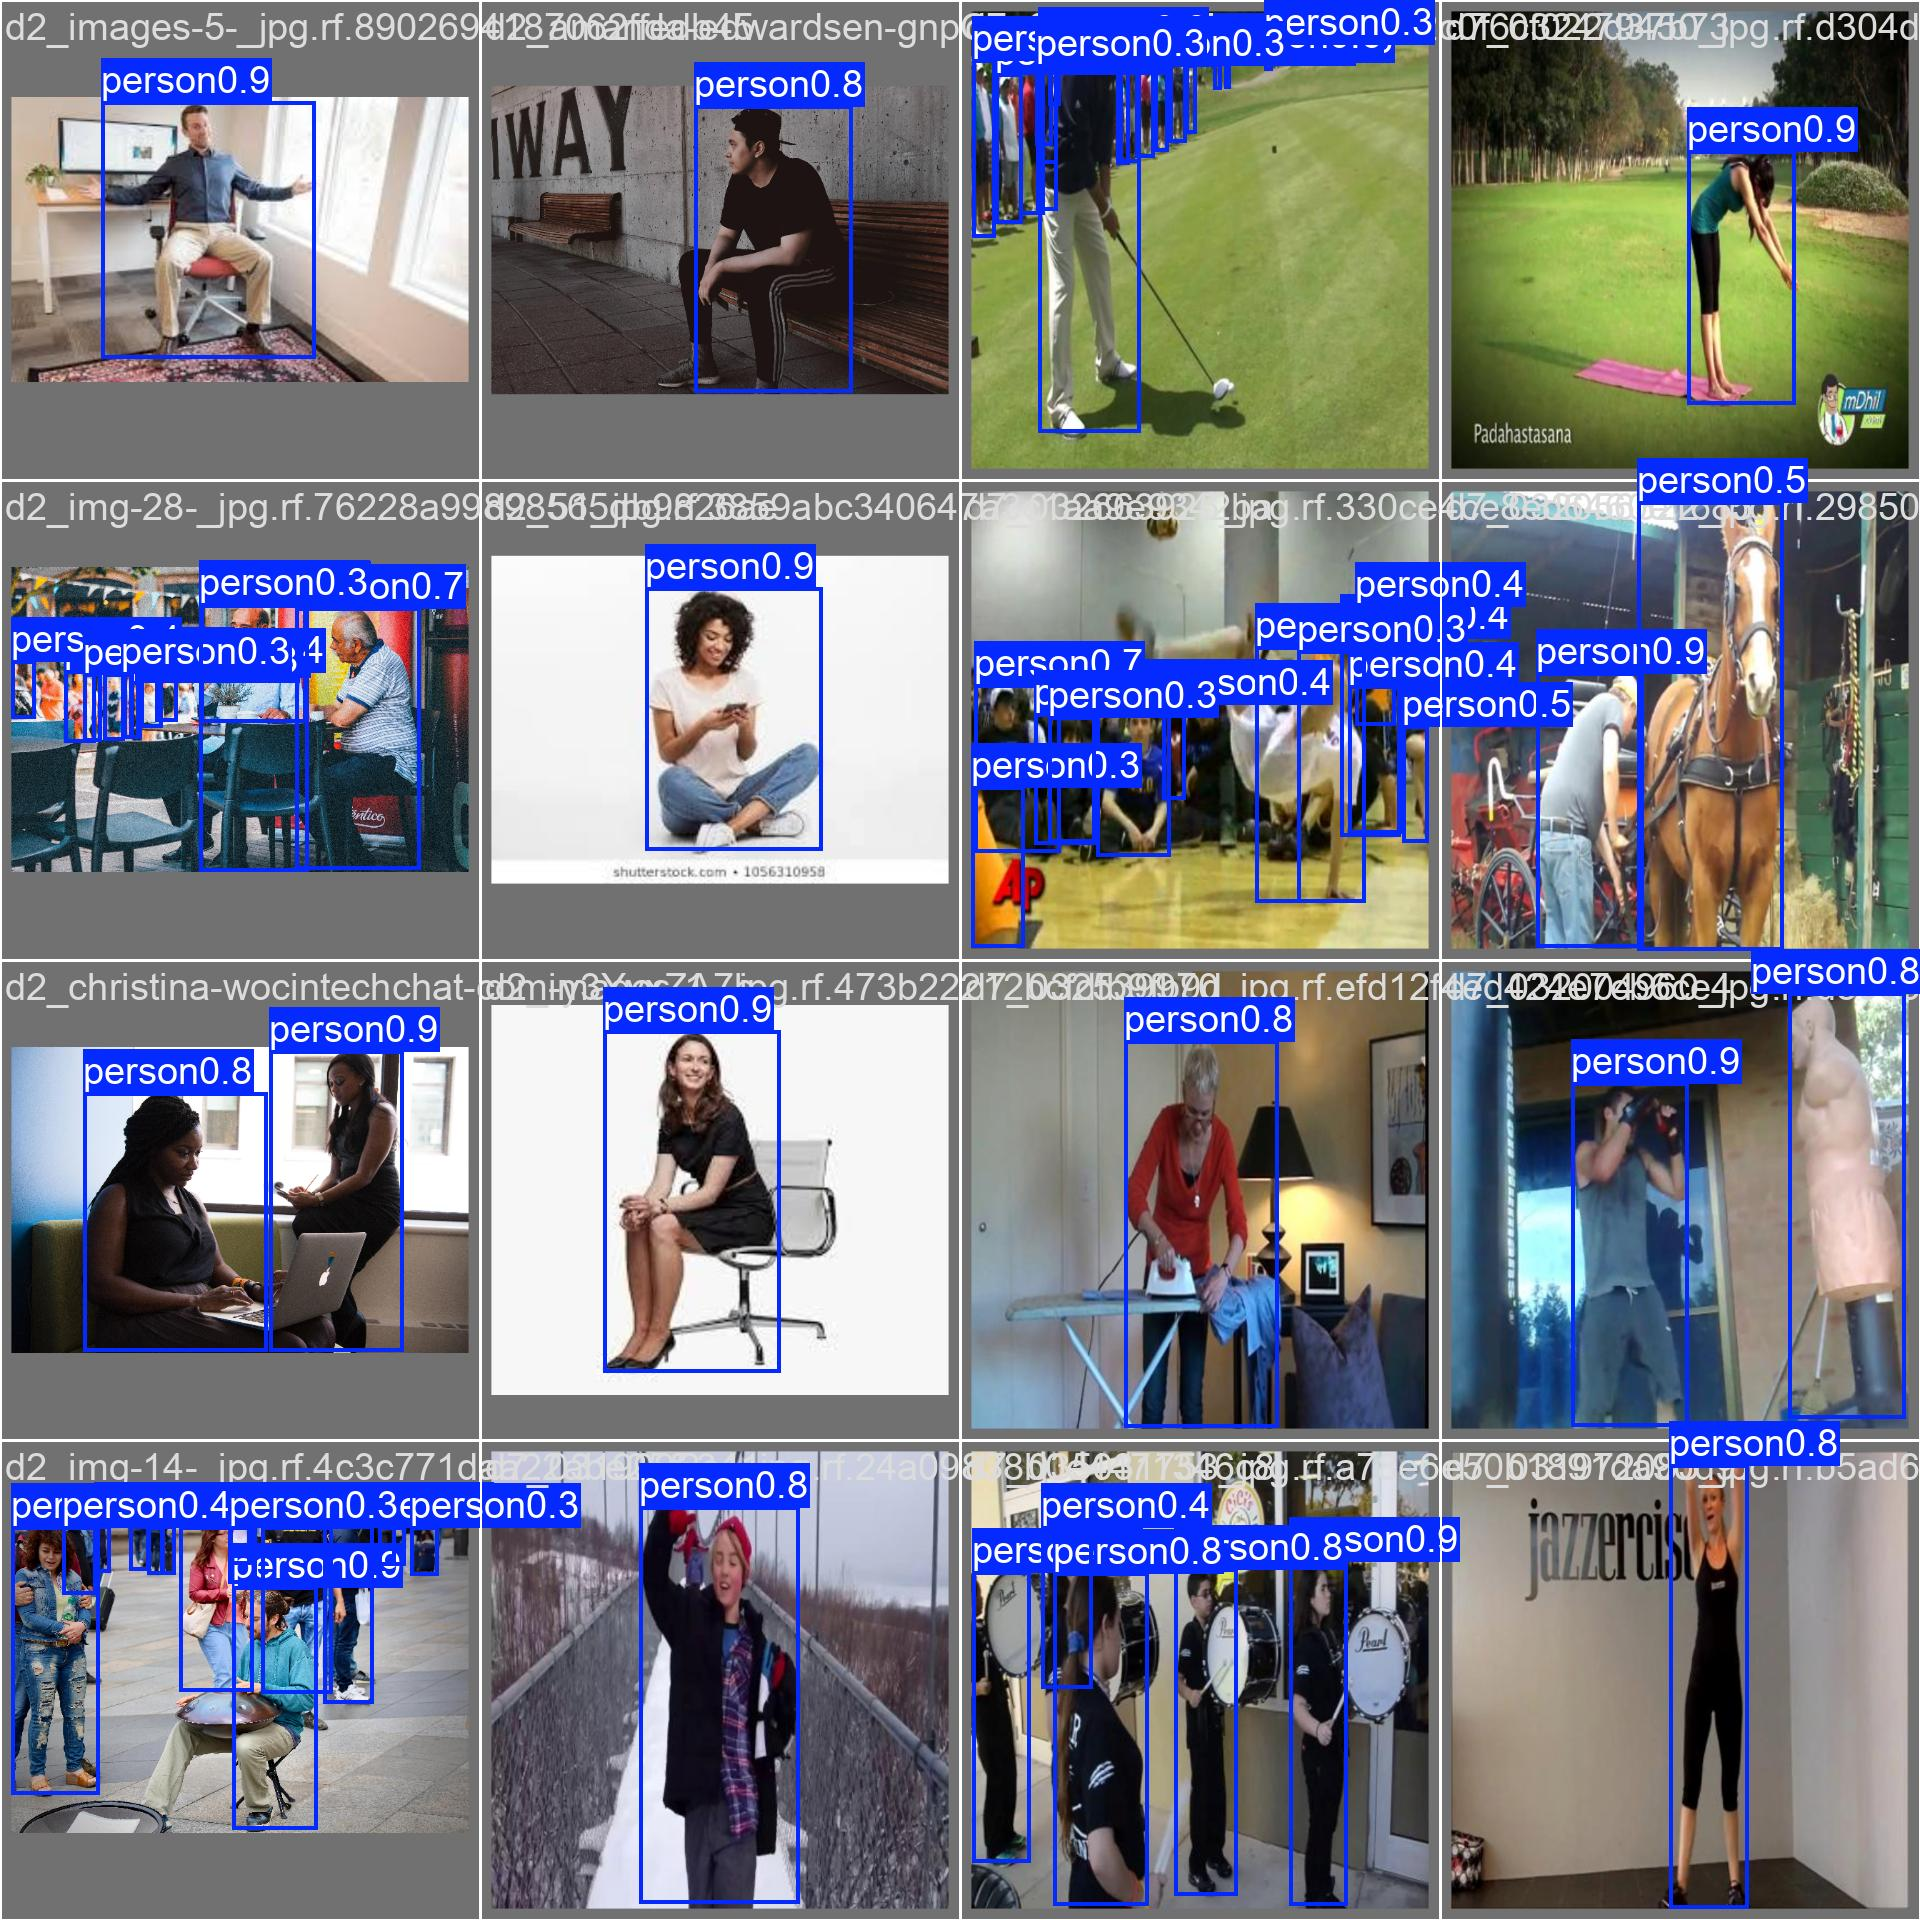

In [20]:
for filename in ['val_batch0_labels.jpg', 'val_batch0_pred.jpg']:
    image_path = MAIN_RUN_DIR / filename
    if image_path.exists():
        print(filename)
        display(Image(filename=str(image_path), width=1000))

<h3 style="color:#111111; border-left:3px solid #111111; padding-left:8px;"> 4. 학습 그래프와 혼동행렬 확인 </h3>

results.png


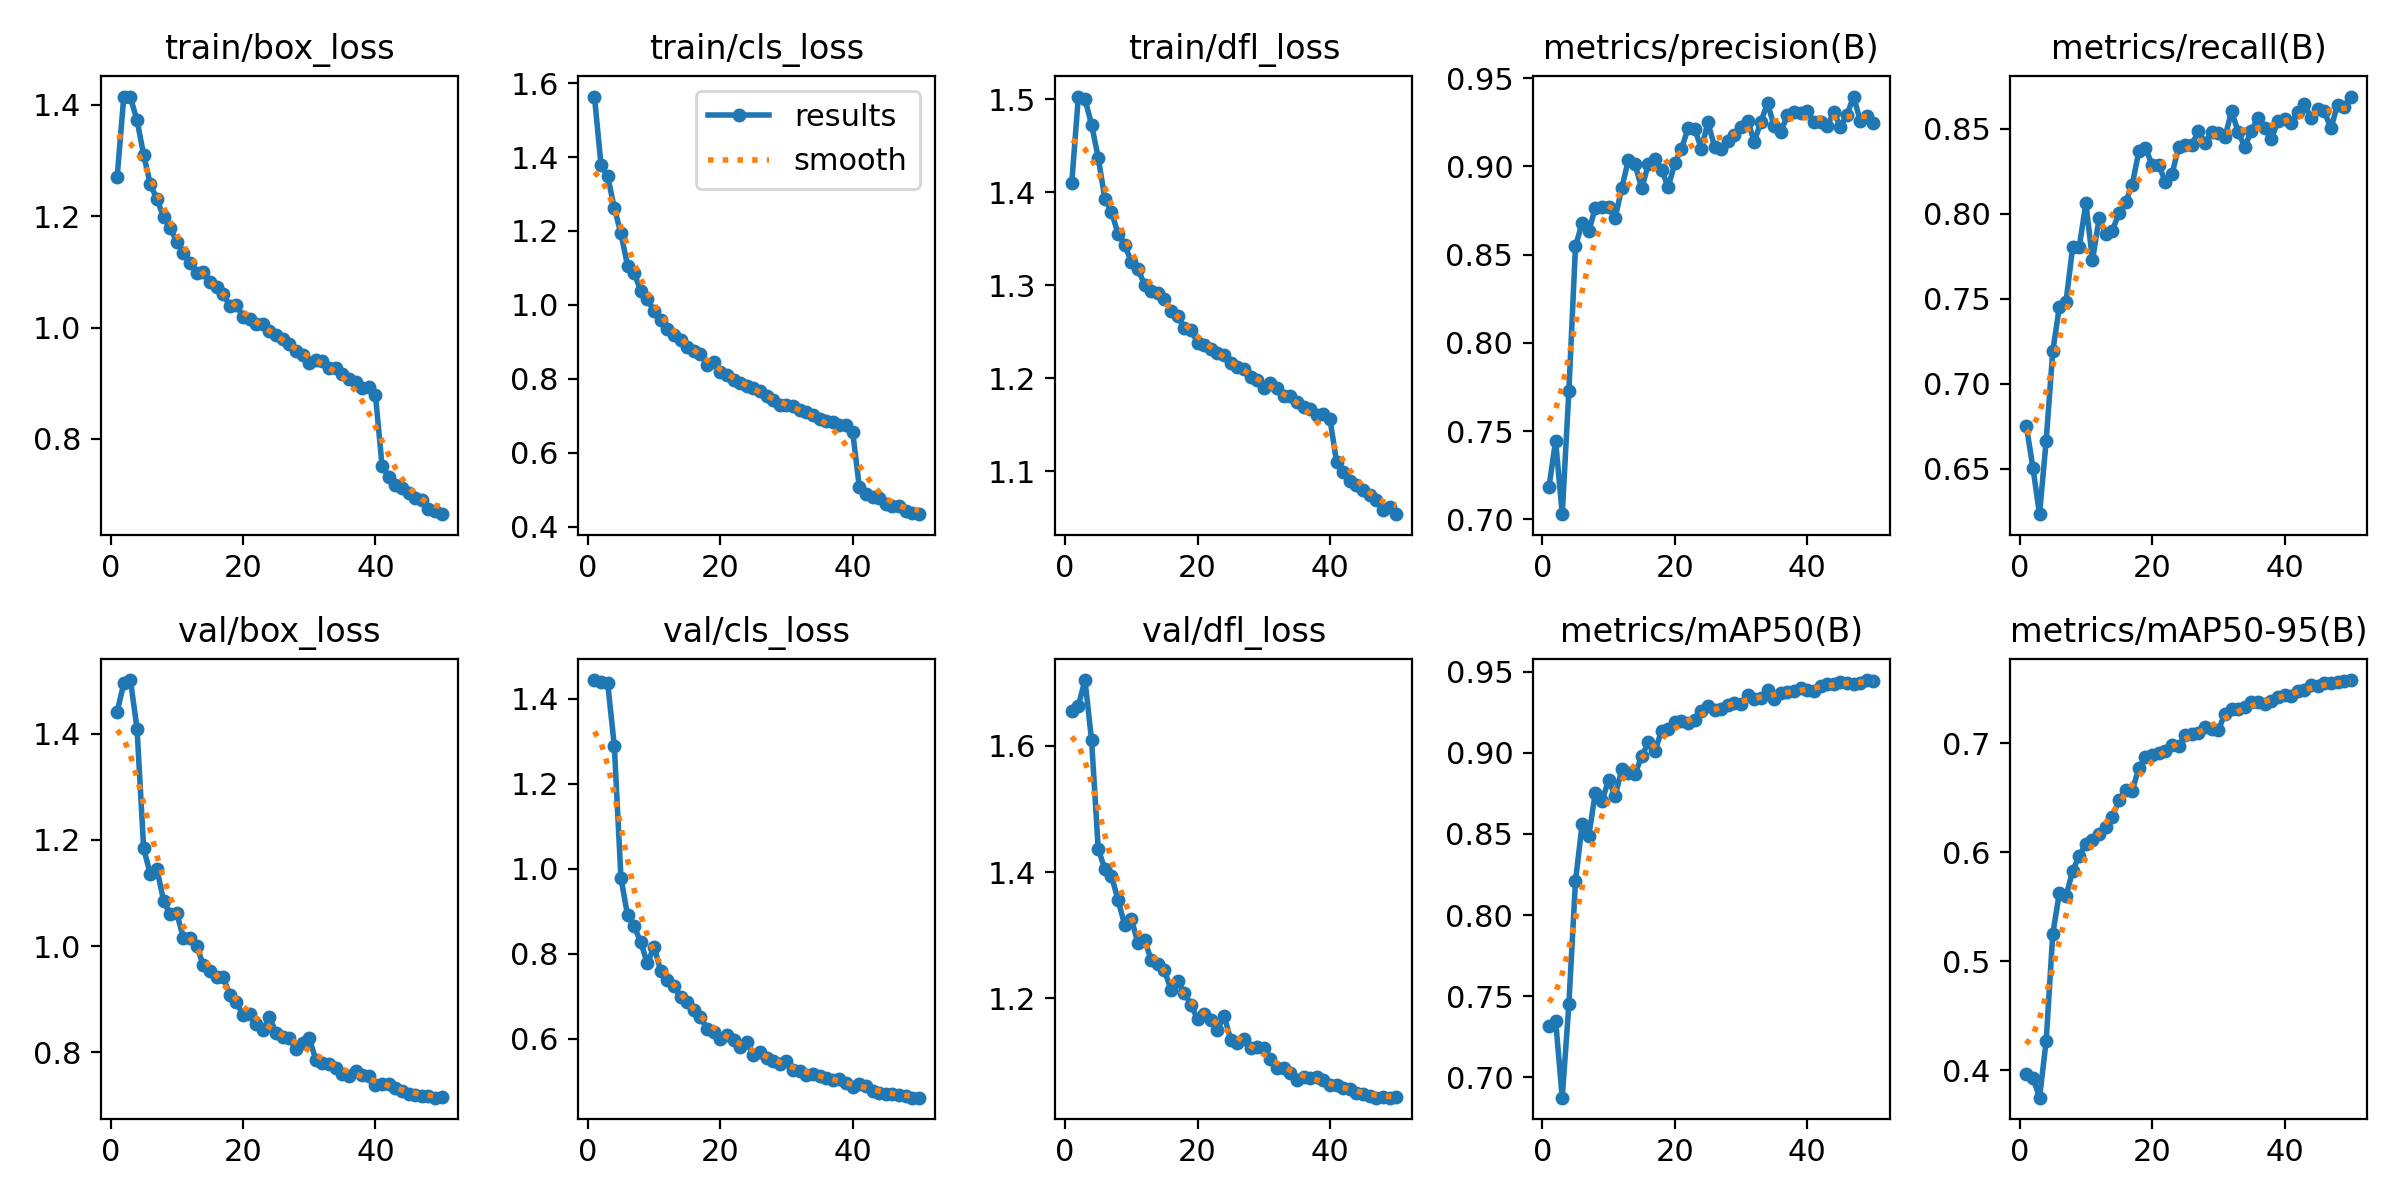

confusion_matrix.png


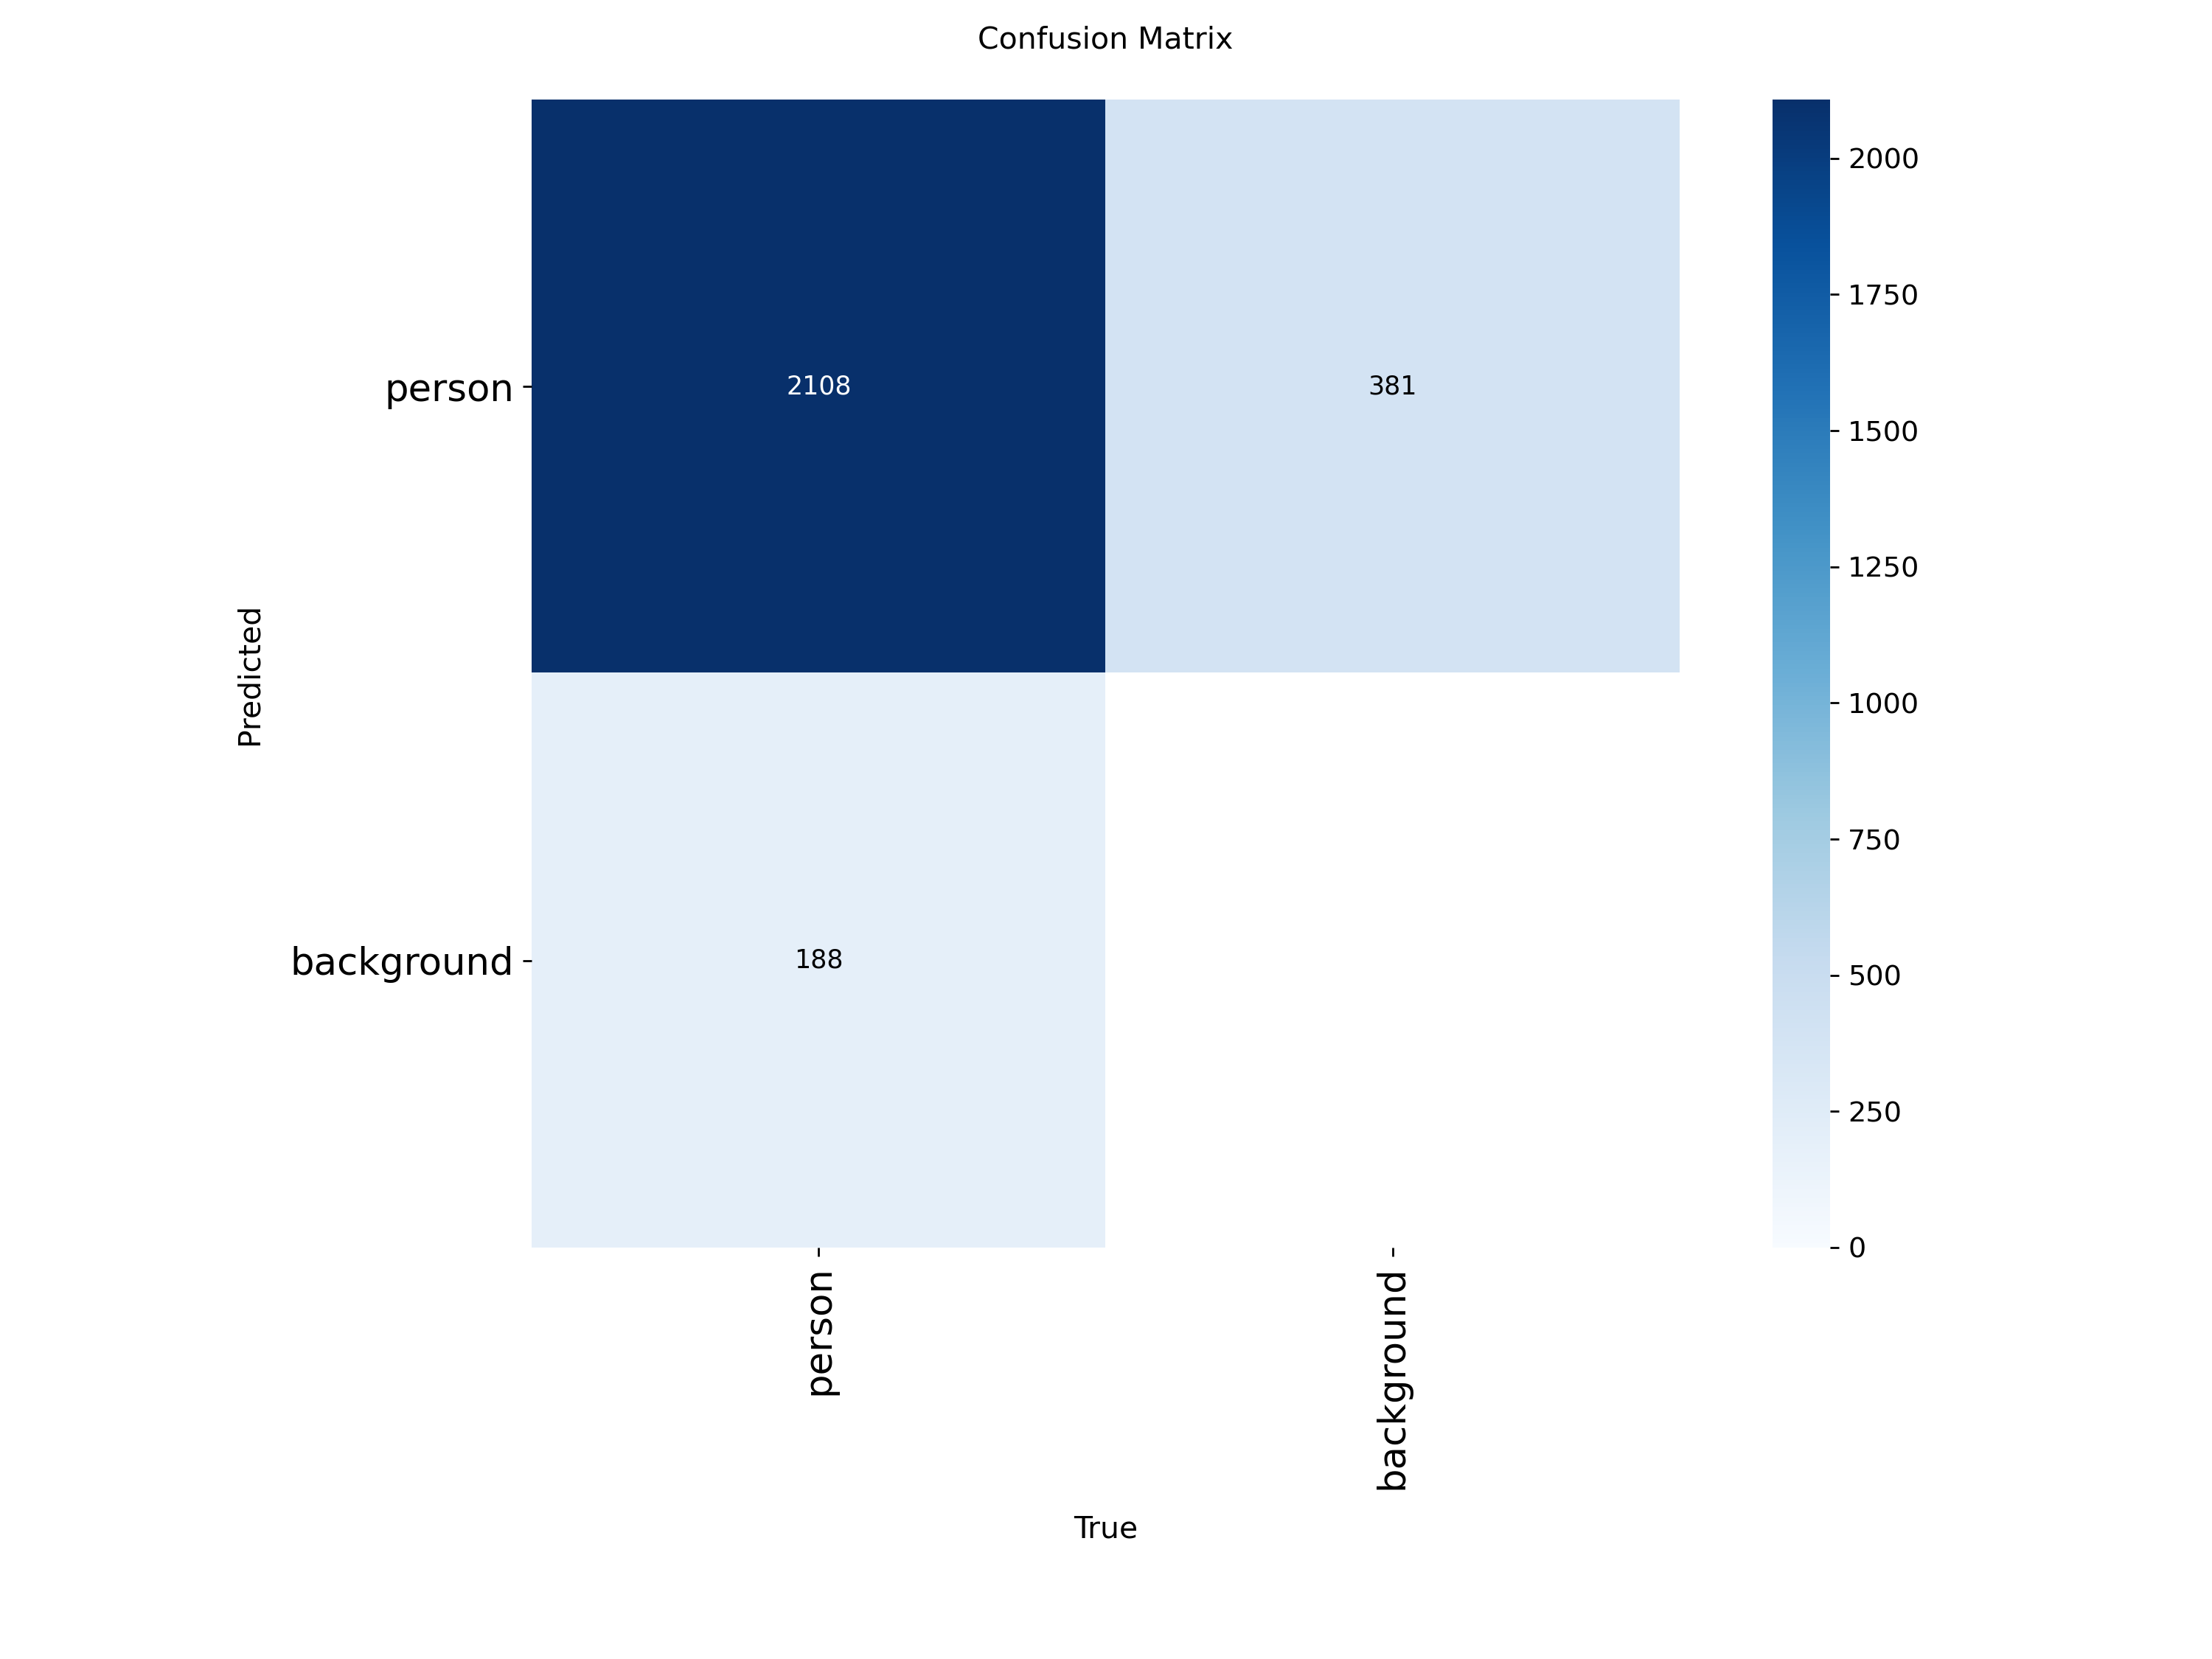

confusion_matrix_normalized.png


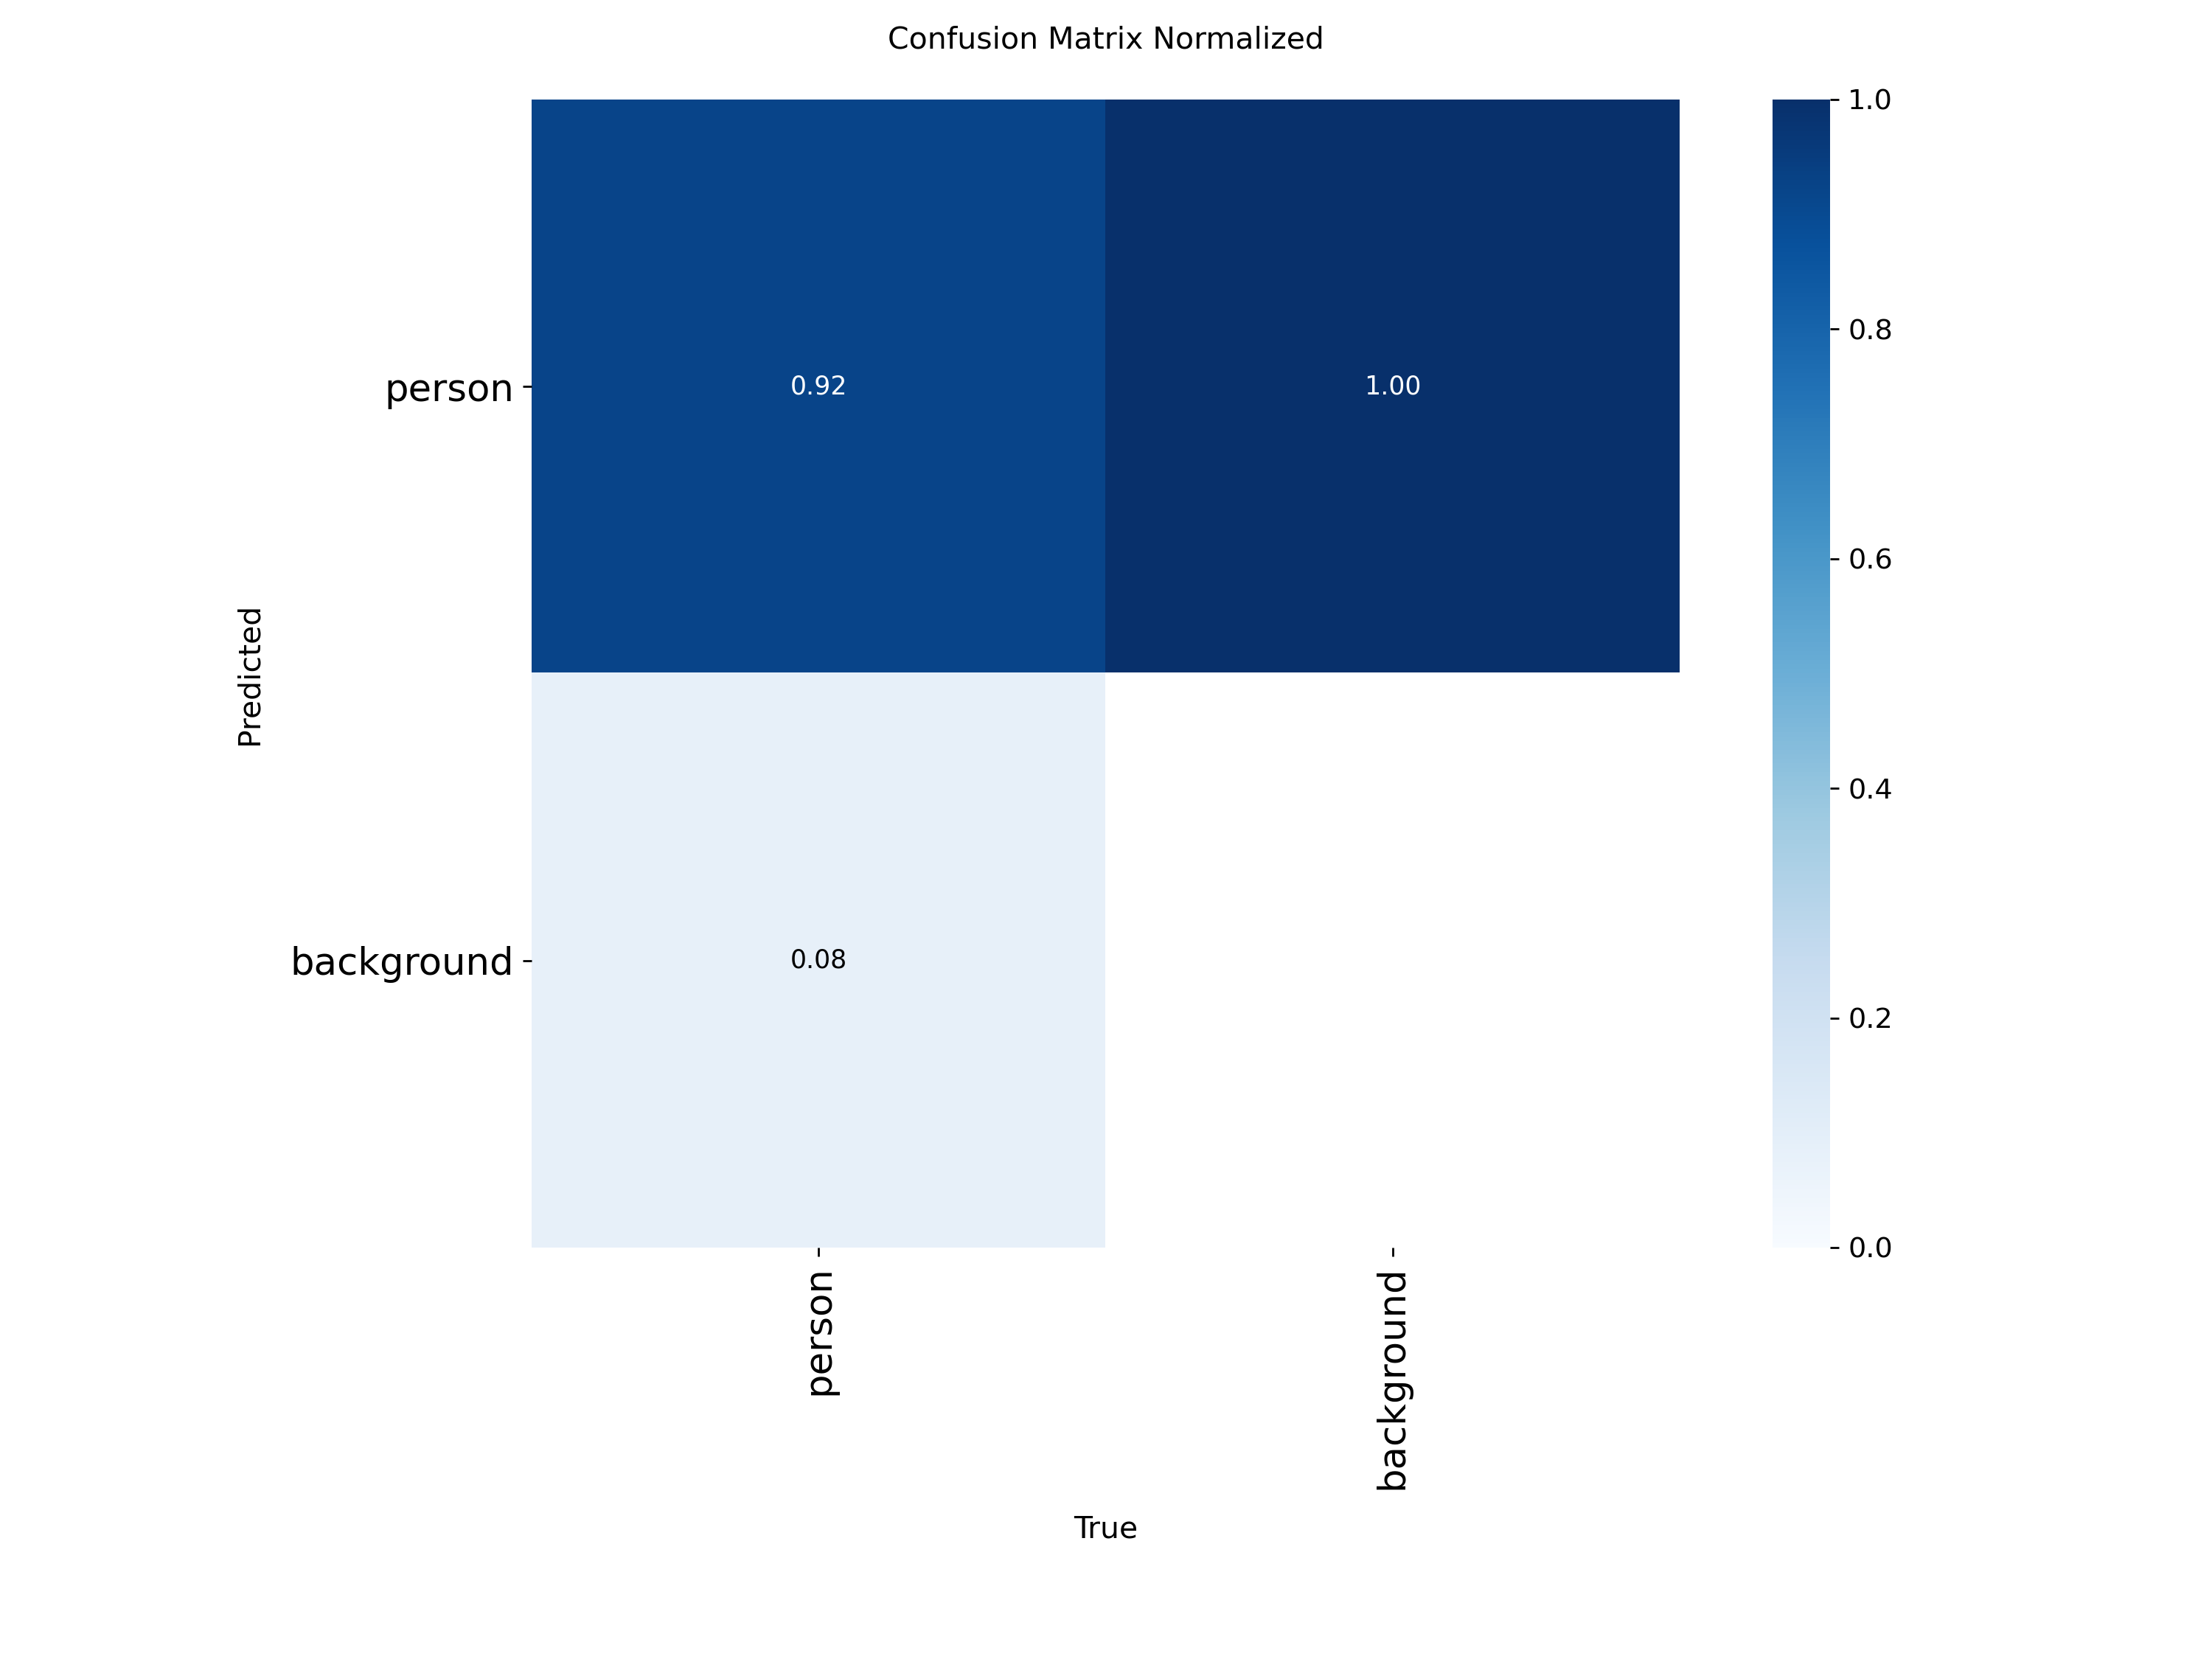

In [21]:
for filename, width in [
    ('results.png', 1100),
    ('confusion_matrix.png', 900),
    ('confusion_matrix_normalized.png', 900),
]:
    image_path = MAIN_RUN_DIR / filename
    if image_path.exists():
        print(filename)
        display(Image(filename=str(image_path), width=width))

<h3 style="color:#111111; border-left:3px solid #111111; padding-left:8px;"> 5. Test 세트 성능 지표와 모델 파일 확인 </h3>

In [22]:
from pathlib import Path
from ultralytics import YOLO
import torch

DEVICE = 0 if torch.cuda.is_available() else 'cpu'

MAIN_RUN_DIR = PROJECT_ROOT / 'ml/src/export/person_detector_training'
DATA_YAML = DATASET_PATH / 'data.yaml'

MAIN_BEST_MODEL = MAIN_RUN_DIR / 'weights' / 'best.pt'
MAIN_LAST_MODEL = MAIN_RUN_DIR / 'weights' / 'last.pt'
TEST_RUN_DIR = MAIN_RUN_DIR / 'test_evaluation'

print('best.pt:', MAIN_BEST_MODEL.exists(), MAIN_BEST_MODEL)
print('last.pt:', MAIN_LAST_MODEL.exists(), MAIN_LAST_MODEL)
print('data.yaml:', DATA_YAML.exists(), DATA_YAML)

if not MAIN_BEST_MODEL.exists():
    raise FileNotFoundError(
        f'본 학습 best.pt를 찾을 수 없습니다: {MAIN_BEST_MODEL}'
    )

if not DATA_YAML.exists():
    raise FileNotFoundError(
        f'data.yaml을 찾을 수 없습니다: {DATA_YAML}'
    )

main_best_model = YOLO(str(MAIN_BEST_MODEL))

main_metrics = main_best_model.val(
    data=str(DATA_YAML),
    split='test',
    imgsz=640,
    device=DEVICE,
    plots=True,
    project=str(MAIN_RUN_DIR),
    name='test_evaluation',
    exist_ok=True,
)

print(f'Precision : {main_metrics.box.mp:.4f}')
print(f'Recall    : {main_metrics.box.mr:.4f}')
print(f'mAP50     : {main_metrics.box.map50:.4f}')
print(f'mAP50-95  : {main_metrics.box.map:.4f}')
print('Test 결과 저장 위치:', TEST_RUN_DIR)

best.pt: True /kaggle/working/wardy/ml/src/export/person_detector_training/weights/best.pt
last.pt: True /kaggle/working/wardy/ml/src/export/person_detector_training/weights/last.pt
data.yaml: True /kaggle/working/person_dataset/data.yaml
Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 887.2±402.4 MB/s, size: 28.1 KB)
val: Scanning /kaggle/working/person_dataset/labels/test.cache... 1178 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1178/1178 449.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 74/74 7.5it/s 9.9s
                   all       1178       2202      0.954      0.876      0.954      0.778
Speed: 0.9ms preprocess, 3.8ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /kaggle/working/wardy/ml/src/export/person_dete

<h3 style="color:#111111; border-left:3px solid #111111; padding-left:8px;"> 6. Test 이미지 사람 탐지 결과 확인 </h3>


image 1/1 /kaggle/working/person_dataset/images/test/d1_frame_0019_jpg.rf.1a8c838a3a2e74ca6c2bab4de4080746.jpg: 640x640 1 person, 7.8ms
Speed: 1.6ms preprocess, 7.8ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/wardy/ml/src/export/person_detector_training/prediction
테스트 이미지: /kaggle/working/person_dataset/images/test/d1_frame_0019_jpg.rf.1a8c838a3a2e74ca6c2bab4de4080746.jpg


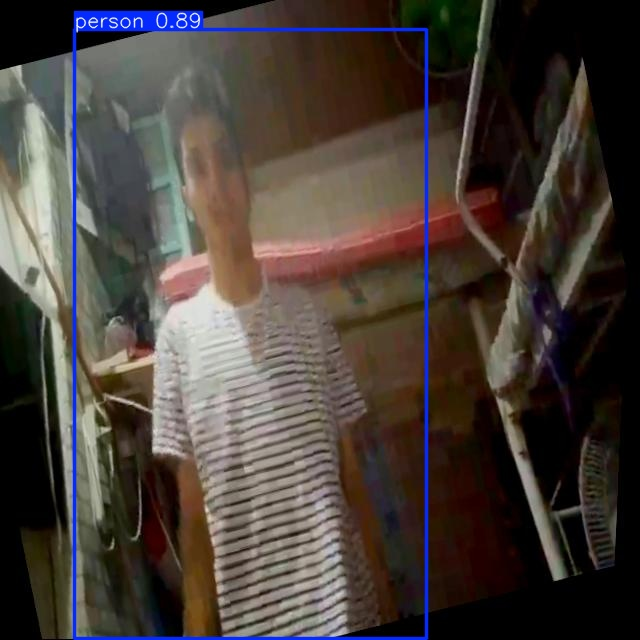

In [23]:
main_test_images = sorted((Path(DATASET_PATH) / 'images' / 'test').glob('*'))
if not main_test_images:
    raise FileNotFoundError('Test 이미지를 찾을 수 없습니다.')

main_prediction_results = main_best_model.predict(
    source=str(main_test_images[0]),
    conf=0.5,
    save=True,
    project=str(MAIN_RUN_DIR),
    name='prediction',
    exist_ok=True,
)
main_result_image = MAIN_RUN_DIR / 'prediction' / main_test_images[0].name
print('테스트 이미지:', main_test_images[0])
if main_result_image.exists():
    display(Image(filename=str(main_result_image), width=1000))

<h3 style="color:#111111; border-left:3px solid #111111; padding-left:8px;">
7. 본 학습 결과 ZIP 생성 및 무결성 검사
</h3>

In [24]:
from pathlib import Path
import shutil
import zipfile

ZIP_PATH = Path(shutil.make_archive(
    '/kaggle/working/person_detector_training_results',
    'zip',
    root_dir=MAIN_RUN_DIR,
))
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_file:
    broken_file = zip_file.testzip()
    file_count = len(zip_file.namelist())
if broken_file is not None:
    raise RuntimeError(f'ZIP 손상 파일: {broken_file}')
print('중간 ZIP 생성 성공:', ZIP_PATH)
print('ZIP 내부 파일 수:', file_count)
print('ONNX·배포 결과까지 포함하려면 16번 배포 요약 셀까지 실행하세요.')

ZIP 존재: True
ZIP 크기: 198.8 MB


<h3 style="color:#111111; border-left:3px solid #111111; padding-left:8px;">
8. 본 학습 결과 ZIP 저장 확인
</h3>

In [25]:
ZIP_PATH = Path('/kaggle/working/person_detector_training_results.zip')
print('ZIP 존재:', ZIP_PATH.is_file())
if not ZIP_PATH.is_file():
    raise FileNotFoundError(f'본 학습 ZIP이 없습니다: {ZIP_PATH}')
print('ZIP 크기:', round(ZIP_PATH.stat().st_size / 1024**2, 1), 'MB')
print('Kaggle 오른쪽 Output에서 다운로드하세요:', ZIP_PATH)

학습 폴더: True
best.pt: True
ZIP 생성 성공: /kaggle/working/person_detector_training_results.zip
ZIP 크기: 202.4 MB
내부 파일 수: 50


<h2 style="color:#111111; border-left:5px solid #111111; padding-left:12px;"> 13. ONNX 배포 모델 생성 </h2>

본 학습의 best.pt를 고정 입력 크기 640의 ONNX로 변환하고 Drive의 deploy 폴더에 보관합니다.

In [26]:
import hashlib
import shutil

DEPLOY_DIR = MAIN_RUN_DIR / 'deploy'
DEPLOY_DIR.mkdir(parents=True, exist_ok=True)
ONNX_MODEL = DEPLOY_DIR / 'person_detector.onnx'

exported_onnx = Path(main_best_model.export(
    format='onnx',
    imgsz=640,
    batch=1,
    dynamic=False,
    simplify=True,
))
if exported_onnx.resolve() != ONNX_MODEL.resolve():
    shutil.copy2(exported_onnx, ONNX_MODEL)
if not ONNX_MODEL.is_file() or ONNX_MODEL.stat().st_size == 0:
    raise RuntimeError(f'ONNX 생성 실패: {ONNX_MODEL}')
onnx_sha256 = hashlib.sha256(ONNX_MODEL.read_bytes()).hexdigest()
print('ONNX:', ONNX_MODEL)
print(f'크기: {ONNX_MODEL.stat().st_size / 1024**2:.1f} MB')
print('SHA-256:', onnx_sha256)

Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/kaggle/working/wardy/ml/src/export/person_detector_training/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (5.2 MB)
requirements: Ultralytics requirements ['onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 417ms
 Downloaded onnxruntime
Prepared 2 packages in 328ms
Installed 2 packages in 13ms
 + onnxruntime==1.28.0
 + onnxslim==0.1.95

requirements: AutoUpdate success ✅ 1.3s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming with onnxslim 0.1.95...
ONNX: export success ✅ 3.2s, saved as '/kaggle/working/wardy/

<h2 style="color:#111111; border-left:5px solid #111111; padding-left:12px;"> 14. PT와 ONNX Test 성능 비교 </h2>

ONNX 모델을 전체 test 세트에서 평가합니다. mAP50 하락이 0.02를 넘으면 배포를 중단합니다.

In [27]:
onnx_model = YOLO(str(ONNX_MODEL))
onnx_metrics = onnx_model.val(
    data=DATA_YAML, split='test', imgsz=640, batch=1, device='cpu', plots=False
)
metric_pairs = {
    'Precision': (float(main_metrics.box.mp), float(onnx_metrics.box.mp)),
    'Recall': (float(main_metrics.box.mr), float(onnx_metrics.box.mr)),
    'mAP50': (float(main_metrics.box.map50), float(onnx_metrics.box.map50)),
    'mAP50-95': (float(main_metrics.box.map), float(onnx_metrics.box.map)),
}
print(f'{"Metric":<12} {"PT":>10} {"ONNX":>10} {"Delta":>10}')
for metric_name, (pt_value, onnx_value) in metric_pairs.items():
    print(f'{metric_name:<12} {pt_value:>10.4f} {onnx_value:>10.4f} {onnx_value - pt_value:>+10.4f}')
MAX_MAP50_DROP = 0.02
map50_drop = metric_pairs['mAP50'][0] - metric_pairs['mAP50'][1]
if map50_drop > MAX_MAP50_DROP:
    raise RuntimeError(f'ONNX mAP50이 PT보다 {map50_drop:.4f} 하락했습니다.')
print('ONNX 성능 검증 통과')

WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify', 'pose', 'obb' or 'semantic'.
Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Loading /kaggle/working/wardy/ml/src/export/person_detector_training/deploy/person_detector.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.28.0 with CPUExecutionProvider
Setting batch=1 input of shape (1, 3, 640, 640)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 842.9±341.4 MB/s, size: 27.7 KB)
val: Scanning /kaggle/working/person_dataset/labels/test.cache... 1178 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1178/1178 411.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1178/1178 14.3it/s 1:23
                   all       1178       2202      0.953      0.871      0.954       0.77
Speed: 1.5ms preprocess, 60.8ms inference, 0.

<h2 style="color:#111111; border-left:5px solid #111111; padding-left:12px;"> 15. ONNX Test 이미지 탐지 확인 </h2>

Loading /kaggle/working/wardy/ml/src/export/person_detector_training/deploy/person_detector.onnx for ONNX Runtime inference...
requirements: Ultralytics requirement ['onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 5 packages in 326ms
 Downloaded onnxruntime-gpu
Prepared 1 package in 2.16s
Installed 1 package in 105ms
 + onnxruntime-gpu==1.28.0

requirements: AutoUpdate success ✅ 2.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

WARNING ⚠️ CUDA requested but CUDAExecutionProvider not available. Using CPU...
Using ONNX Runtime 1.28.0 with CPUExecutionProvider

image 1/1 /kaggle/working/person_dataset/images/test/d1_frame_0019_jpg.rf.1a8c838a3a2e74ca6c2bab4de4080746.jpg: 640x640 1 person, 64.0ms
Speed: 2.1ms preprocess, 64.0ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/wardy/ml/src/export/person_detector_training/deploy/onnx_prediction


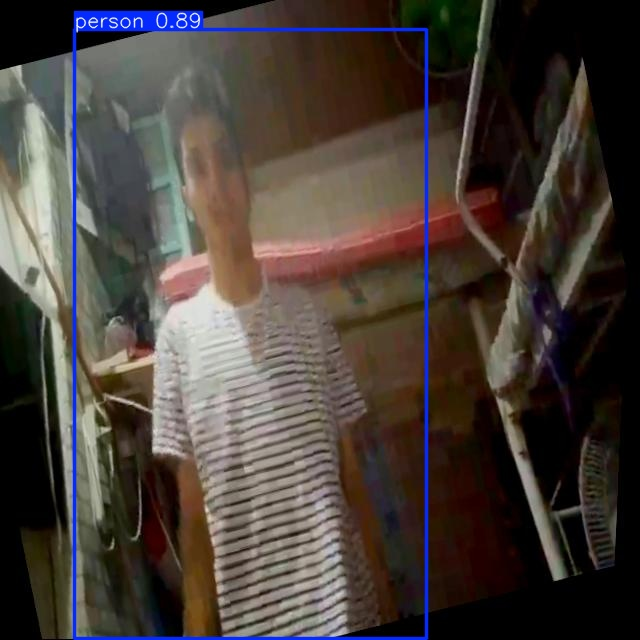

In [28]:
onnx_prediction_results = onnx_model.predict(
    source=str(main_test_images[0]), imgsz=640, conf=0.5, save=True,
    project=str(DEPLOY_DIR), name='onnx_prediction', exist_ok=True,
)
onnx_result_image = DEPLOY_DIR / 'onnx_prediction' / main_test_images[0].name
if onnx_result_image.exists():
    display(Image(filename=str(onnx_result_image), width=1000))

<h2 style="color:#111111; border-left:5px solid #111111; padding-left:12px;"> 16. 배포 파일과 Jetson 엔진 생성 </h2>

In [29]:
summary_lines = [
    'Wardy Person Detector Deployment',
    f'PT model: {MAIN_BEST_MODEL}',
    f'ONNX model: {ONNX_MODEL}',
    f'ONNX SHA-256: {onnx_sha256}',
    'Input: 1x3x640x640',
    'Class 0: person',
    '',
]
for metric_name, (pt_value, onnx_value) in metric_pairs.items():
    summary_lines.append(
        f'{metric_name}: PT={pt_value:.4f}, ONNX={onnx_value:.4f}, delta={onnx_value - pt_value:+.4f}'
    )
DEPLOYMENT_SUMMARY = DEPLOY_DIR / 'deployment_summary.txt'
DEPLOYMENT_SUMMARY.write_text('\n'.join(summary_lines) + '\n', encoding='utf-8')
print(DEPLOYMENT_SUMMARY.read_text(encoding='utf-8'))
print('Jetson으로 복사할 파일:', ONNX_MODEL)

# Test 평가, 예측, ONNX와 배포 요약까지 포함한 최종 ZIP을 다시 생성합니다.
import zipfile

FINAL_RESULT_ZIP = Path(shutil.make_archive(
    '/kaggle/working/person_detector_training_results',
    'zip',
    root_dir=MAIN_RUN_DIR,
))
with zipfile.ZipFile(FINAL_RESULT_ZIP, 'r') as zip_file:
    broken_file = zip_file.testzip()
    final_file_count = len(zip_file.namelist())
if broken_file is not None:
    raise RuntimeError(f'최종 ZIP 손상 파일: {broken_file}')

required_archive_entries = [
    'weights/best.pt',
    'results.csv',
    'results.png',
    'deploy/person_detector.onnx',
    'deploy/deployment_summary.txt',
]
with zipfile.ZipFile(FINAL_RESULT_ZIP, 'r') as zip_file:
    archive_names = set(zip_file.namelist())
missing_entries = [name for name in required_archive_entries if name not in archive_names]
if missing_entries:
    raise RuntimeError(f'최종 ZIP 필수 파일 누락: {missing_entries}')

print('최종 결과 ZIP 생성 및 검증 완료:', FINAL_RESULT_ZIP)
print('ZIP 크기:', round(FINAL_RESULT_ZIP.stat().st_size / 1024**2, 1), 'MB')
print('ZIP 내부 파일 수:', final_file_count)
print('Kaggle 오른쪽 Output에서 ZIP과 download 폴더의 모델을 다운로드하세요.')

Wardy Person Detector Deployment
PT model: /kaggle/working/wardy/ml/src/export/person_detector_training/weights/best.pt
ONNX model: /kaggle/working/wardy/ml/src/export/person_detector_training/deploy/person_detector.onnx
ONNX SHA-256: 8bd2e16601b4dcfc98f4b048d770e2aacfc0260832869fc24d55fe77291c3780
Input: 1x3x640x640
Class 0: person

Precision: PT=0.9537, ONNX=0.9533, delta=-0.0004
Recall: PT=0.8760, ONNX=0.8709, delta=-0.0051
mAP50: PT=0.9543, ONNX=0.9545, delta=+0.0002
mAP50-95: PT=0.7784, ONNX=0.7698, delta=-0.0086

Jetson으로 복사할 파일: /kaggle/working/wardy/ml/src/export/person_detector_training/deploy/person_detector.onnx


### Jetson에서 TensorRT 엔진 생성

TensorRT 엔진은 Colab T4가 아니라 실제 사용할 Jetson에서 생성해야 합니다. 저장소와 person_detector.onnx를 Jetson으로 복사한 뒤 실행하세요.

<pre>chmod +x edge/scripts/build_person_detector_engine.sh
./edge/scripts/build_person_detector_engine.sh /path/to/person_detector.onnx /path/to/person_detector.engine</pre>

기존 엔진을 다시 만들 때만 마지막에 --force를 추가하세요. 스크립트는 Jetson 여부와 trtexec를 확인하고 FP16 엔진 생성 후 로드 벤치마크까지 수행합니다.